# Entrega 2 - PLN | Clasificación de reseñas de Amazon en español con Transformers desde cero

## Experimento 1: cinco estrellas · Experimento 2: tres sentimientos

**Curso:** Procesamiento del lenguaje natural  
**Autor(es):**  
- Camilo Camero
- Andres Cuellar
- Andres Gonzalez
- Julian Salamanca

En la entrega 1 construimos clasificadores de reseñas con TF-IDF y redes recurrentes (LSTM/BiLSTM) usando una muestra de 25.000 reseñas. En esta entrega damos el siguiente paso: **implementamos un Transformer (encoder) pieza por pieza**, lo entrenamos con **las 200 mil reseñas del dataset** y lo ponemos a competir contra los modelos de la entrega anterior en los mismos dos experimentos.

## 1. ¿Cuál es el problema que queremos resolver?

Hoy en día, las tiendas online como Amazon reciben miles y miles de reseñas. Leerlas una por una es imposible. Si logramos automatizar esto, podemos saber rápidamente si los clientes están felices o enojados, y detectar problemas a tiempo.

**Nuestro objetivo:** Seguimos probando dos formas de analizar estas reseñas:
- **Experimento 1:** Que el modelo adivine exactamente cuántas estrellas (del 1 al 5) le dio el usuario.
- **Experimento 2:** Algo más sencillo. Agrupar las reseñas en 3 sentimientos: Negativo, Neutral y Positivo.

### Definición de las dos variables objetivo

| Etiqueta original | Estrellas | Experimento 1 | Experimento 2 | ID sentimiento |
|---:|---:|---|---|---:|
| 0 | 1 | 1 estrella | Negativo | 0 |
| 1 | 2 | 2 estrellas | Negativo | 0 |
| 2 | 3 | 3 estrellas | Neutral | 1 |
| 3 | 4 | 4 estrellas | Positivo | 2 |
| 4 | 5 | 5 estrellas | Positivo | 2 |

La calificación funciona como una **aproximación al sentimiento**. No es una anotación lingüística independiente: una reseña puede mezclar elogios y críticas o asignar estrellas que no coinciden completamente con su texto.

## 2. Preparando nuestro equipo de trabajo

Para comenzar debemos instalar las siguientes herramientas (spaCy, PyTorch Lightning, scikit-learn, transformers, tokenizers de Hugging Face).

In [29]:
%pip install -q datasets lightning torchmetrics scikit-learn seaborn spacy transformers tokenizers ipywidgets

In [30]:
# Modelo mediano de spaCy en español; se usa solo en la exploración de embeddings.
!python -m spacy download es_core_news_md -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 14.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [31]:
import gc
import html
import logging
import math
import os
import re
import time
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

from datasets import load_dataset
from IPython.display import HTML, Markdown, display

import spacy
from scipy.spatial.distance import cosine
from scipy.stats import binomtest, chi2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset, DataLoader, Sampler

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

from tokenizers.pre_tokenizers import ByteLevel
from transformers import AutoTokenizer

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Silenciamos los mensajes informativos de Lightning para que la salida sea legible.
for logger_name in ["lightning", "lightning.pytorch", "lightning.fabric"]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
L.seed_everything(SEED, workers=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 160)

print(f"Dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: cuda
GPU: Tesla T4
PyTorch: 2.11.0+cu128


### Interruptores de los experimentos

Como hay muchos entrenamientos, dejamos interruptores para poder apagar partes del notebook mientras iteramos. **Para la entrega final todos van en `True`.**

In [32]:
RUN_RECURRENT_MODELS = True        # LSTM unidireccional (baseline neuronal)
RUN_TRANSFORMER_MODELS = True      # Transformers principales (mini, base, profundo)
RUN_TRANSFORMER_ABLATIONS = True   # Ablaciones: PE aprendible, pooling [CLS], sin posición
RUN_DATA_SIZE_EXPERIMENT = True    # Curva de aprendizaje con 25k, 50k y 100k reseñas

MAX_EPOCHS_LSTM = 5
MAX_EPOCHS_TRANSFORMER = 6
EARLY_STOPPING_PATIENCE = 2

OUTPUT_DIR = Path("resultados")
OUTPUT_DIR.mkdir(exist_ok=True)


def hallazgo(texto):
    """Muestra un hallazgo calculado con los datos reales de la ejecución."""
    display(Markdown(f"> 🔎 **Hallazgo:** {texto}"))

## 3. Cargando y limpiando los datos

Este dataset contiene un total de 200 mil reseñas de entrenamiento, 5 mil de validación y otras 5 mil de prueba, todas en español. Lo bajamos desde la URL de Hugging Face; por lo tanto, la reproducibilidad del taller está ligada a la disponibilidad de esa fuente.

Respetamos las separaciones oficiales para que el modelo no haga trampa estudiando las preguntas del examen final.

In [33]:
BASE_URL = "https://huggingface.co/datasets/mteb/amazon_reviews_multi/resolve/main/es/"
DATA_FILES = {
    "train": BASE_URL + "train.jsonl",
    "validation": BASE_URL + "validation.jsonl",
    "test": BASE_URL + "test.jsonl",
}

raw_dataset = load_dataset("json", data_files=DATA_FILES)
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})

In [34]:
def prepare_frame(split):
    frame = split.to_pandas()[["id", "text", "label"]].copy()
    frame["label"] = frame["label"].astype(int)
    frame["stars"] = frame["label"] + 1
    frame["sentiment"] = np.select(
        [frame["label"] <= 1, frame["label"] == 2],
        [0, 1],
        default=2,
    ).astype(int)
    return frame

full_train_df = prepare_frame(raw_dataset["train"])
full_val_df = prepare_frame(raw_dataset["validation"])
full_test_df = prepare_frame(raw_dataset["test"])

for name, frame in {
    "Entrenamiento": full_train_df,
    "Validación": full_val_df,
    "Prueba": full_test_df,
}.items():
    print(f"{name:>13}: {len(frame):>7,} | {frame['label'].value_counts().sort_index().to_dict()}")

display(full_train_df.head())

Entrenamiento: 200,000 | {0: 40000, 1: 40000, 2: 40000, 3: 40000, 4: 40000}
   Validación:   5,000 | {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}
       Prueba:   5,000 | {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}


,id,text,label,stars,sentiment
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante,0,1,0
1,es_0869872,"Dinero tirado a la basura con esta compra\n\nHorrible, nos tuvimos que comprar otro porque ni nosotros que sabemos inglés, ni un informático, después de una...",0,1,0
2,es_0811721,"solo llega una unidad cuando te obligan a comprar dos\n\nTe obligan a comprar dos unidades y te llega solo una y no hay forma de reclamar, una autentica est...",0,1,0
3,es_0359921,"PRODUCTO NO RECIBIDO.\n\nNo entro en descalificar al vendedor, solo puedo decir que tras dos meses de espera.... sigo sin el producto y tuve que contactar c...",0,1,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,1,0


### Calidad de datos

Para el desarrollo de este proyecto es necesario trabajar con las 200 mil reseñas puesto que los Transformers entrenados desde cero necesitan mucha más información para evitar el sobreajuste:

Después de la revisión:
1. Quitamos los textos contradictorios.
2. Quitamos cualquier reseña de entrenamiento que también esté en validación o prueba (fuga de información).
3. Dejamos una sola copia de los duplicados restantes.

In [35]:
labels_per_text = full_train_df.groupby("text")["label"].nunique()
conflicting_texts = set(labels_per_text[labels_per_text > 1].index)
blocked_texts = set(full_val_df["text"]) | set(full_test_df["text"])

quality = pd.Series({
    "Nulos en entrenamiento original": full_train_df["text"].isna().sum(),
    "Textos vacíos": (full_train_df["text"].str.strip() == "").sum(),
    "IDs repetidos": full_train_df["id"].duplicated().sum(),
    "Duplicados internos originales": full_train_df["text"].duplicated().sum(),
    "Textos duplicados con etiquetas contradictorias": len(conflicting_texts),
    "Coincidencias train-validation": full_train_df["text"].isin(set(full_val_df["text"])).sum(),
    "Coincidencias train-test": full_train_df["text"].isin(set(full_test_df["text"])).sum(),
    "Coincidencias validation-test": full_val_df["text"].isin(set(full_test_df["text"])).sum(),
}, name="Cantidad")
display(quality.to_frame())

train_df = (
    full_train_df
    .loc[lambda frame: ~frame["text"].isin(conflicting_texts | blocked_texts)]
    .drop_duplicates(subset="text")
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)
val_df = full_val_df.reset_index(drop=True).copy()
test_df = full_test_df.reset_index(drop=True).copy()

removed = len(full_train_df) - len(train_df)
print(f"Reseñas de entrenamiento después de la limpieza: {len(train_df):,} (se eliminaron {removed:,})")

,Cantidad
Nulos en entrenamiento original,0
Textos vacíos,0
IDs repetidos,0
Duplicados internos originales,274
Textos duplicados con etiquetas contradictorias,62
Coincidencias train-validation,20
Coincidencias train-test,32
Coincidencias validation-test,2


Reseñas de entrenamiento después de la limpieza: 199,649 (se eliminaron 351)


In [36]:
STAR_NAMES = ["1 estrella", "2 estrellas", "3 estrellas", "4 estrellas", "5 estrellas"]
SENTIMENT_NAMES = ["Negativo", "Neutral", "Positivo"]

sample_summary = pd.DataFrame({
    "Estrellas_train": train_df["label"].value_counts().sort_index(),
    "Estrellas_val": val_df["label"].value_counts().sort_index(),
    "Estrellas_test": test_df["label"].value_counts().sort_index(),
})
sample_summary.index = STAR_NAMES
display(sample_summary)

sentiment_summary = pd.DataFrame({
    "Sentimiento_train": train_df["sentiment"].value_counts().sort_index(),
    "Sentimiento_val": val_df["sentiment"].value_counts().sort_index(),
    "Sentimiento_test": test_df["sentiment"].value_counts().sort_index(),
})
sentiment_summary.index = SENTIMENT_NAMES
display(sentiment_summary)

,Estrellas_train,Estrellas_val,Estrellas_test
1 estrella,39957,1000,1000
2 estrellas,39976,1000,1000
3 estrellas,39921,1000,1000
4 estrellas,39890,1000,1000
5 estrellas,39905,1000,1000


,Sentimiento_train,Sentimiento_val,Sentimiento_test
Negativo,79933,2000,2000
Neutral,39921,1000,1000
Positivo,79795,2000,2000


### Las reglas del juego para comparar justamente

- **Entrenamiento:** todas las reseñas limpias (~40 mil por estrella). **TF-IDF, LSTM y Transformer usan exactamente las mismas.**
- **Validación y Prueba:** las mismas 5.000 oficiales de siempre, así los números son comparables con la entrega 1.

Como usar todo el conjunto multiplica el tiempo de cómputo, lo compensamos así: pre-tokenizamos todo una sola vez y usamos relleno dinámico (sección 7).

## 4. Echando un vistazo a los datos (Análisis exploratorio)

En esta entrega hacemos el EDA sobre **todo** el conjunto de entrenamiento.

Primero calculamos algunas columnas de apoyo para las tres particiones.

In [37]:
TOKEN_PATTERN = re.compile(r"[a-záéíóúüñ0-9]+", flags=re.IGNORECASE)


def simple_tokenizer(text):
    return TOKEN_PATTERN.findall(str(text).lower())


def add_text_features(frame):
    """Agrega título, cuerpo, longitudes y texto en minúsculas."""
    has_separator = frame["text"].str.contains("\n\n", regex=False)
    parts = frame["text"].str.split("\n\n", n=1, expand=True).reindex(columns=[0, 1])
    frame["has_title"] = has_separator
    frame["title"] = parts[0].where(has_separator, "").fillna("").str.strip()
    frame["body"] = parts[1].where(has_separator, frame["text"]).fillna("").str.strip()
    frame["text_lower"] = frame["text"].str.lower()
    frame["n_chars"] = frame["text"].str.len()
    frame["n_words"] = frame["text"].map(lambda text: len(simple_tokenizer(text)))
    frame["title_words"] = frame["title"].map(lambda text: len(simple_tokenizer(text)))
    return frame


for frame in (train_df, val_df, test_df):
    add_text_features(frame)

print(f"Reseñas con estructura título + cuerpo: {train_df['has_title'].mean():.2%}")
display(train_df[["title", "body", "stars"]].head())

Reseñas con estructura título + cuerpo: 100.00%


,title,body,stars
0,José A.,"El producto está para 5 🌟, la calidad y precio bien. Pero le pongo 3, por el servicio de mensajería de Amazon Logistics....entregar aún vecino el paquete......",3
1,Pésimo,El puerto de carga del extensor funciona pero la entrada de auriculares no.,1
2,Muy práctica,Me ha gustado mucho el diseño la utilizo para un rincón de lectura.,4
3,Dados repetidos,Venían dos dados repetidos así no se puede jugar,1
4,Fatal,"Fatal, se me ha roto a los 3 meses y tengo que estarme 15 días sin mando porque se tiene que enviar al servicio técnico de sony",1


### 4.1 ¿Cómo se reparten las clases?

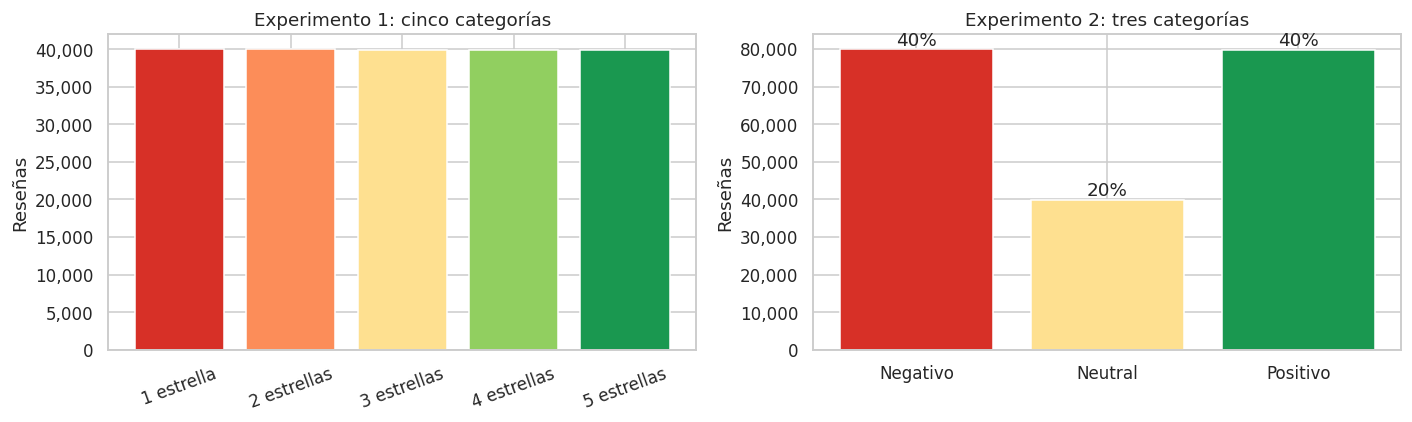

> 🔎 **Hallazgo:** En 5 estrellas cada clase tiene alrededor de 39,930 reseñas. En 3 sentimientos la clase más grande es 2.0 veces la más pequeña (*Neutral*), por eso usamos pesos por clase y macro-F1.

In [38]:
STAR_COLORS = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
SENTIMENT_COLORS = [STAR_COLORS[0], STAR_COLORS[2], STAR_COLORS[4]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
star_counts = train_df["label"].value_counts().sort_index()
sentiment_counts = train_df["sentiment"].value_counts().sort_index()

axes[0].bar(STAR_NAMES, star_counts.values, color=STAR_COLORS)
axes[0].set_title("Experimento 1: cinco categorías")
axes[0].set_ylabel("Reseñas")
axes[0].tick_params(axis="x", rotation=20)

bars = axes[1].bar(SENTIMENT_NAMES, sentiment_counts.values, color=SENTIMENT_COLORS)
axes[1].bar_label(bars, labels=[f"{value / sentiment_counts.sum():.0%}" for value in sentiment_counts.values])
axes[1].set_title("Experimento 2: tres categorías")
axes[1].set_ylabel("Reseñas")

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{int(value):,}"))
plt.tight_layout()
plt.show()

ratio = sentiment_counts.max() / sentiment_counts.min()
hallazgo(
    f"En 5 estrellas cada clase tiene alrededor de {star_counts.mean():,.0f} reseñas. "
    f"En 3 sentimientos la clase más grande es {ratio:.1f} veces la más pequeña (*Neutral*), "
    "por eso usamos pesos por clase y macro-F1."
)

### 4.2 ¿Qué tan largas son las reseñas?

,n_chars,n_words
count,199649.00,199649.00
mean,172.63,31.19
std,136.02,24.84
min,22.00,3.00
50%,140.00,25.00
75%,210.00,38.00
90%,323.00,59.00
95%,420.00,76.00
99%,699.00,127.00
max,3162.00,566.00


,mean,median,max
stars,,,
1,32.1,26.0,414
2,35.1,28.0,511
3,32.3,26.0,466
4,29.0,24.0,390
5,27.5,22.0,566


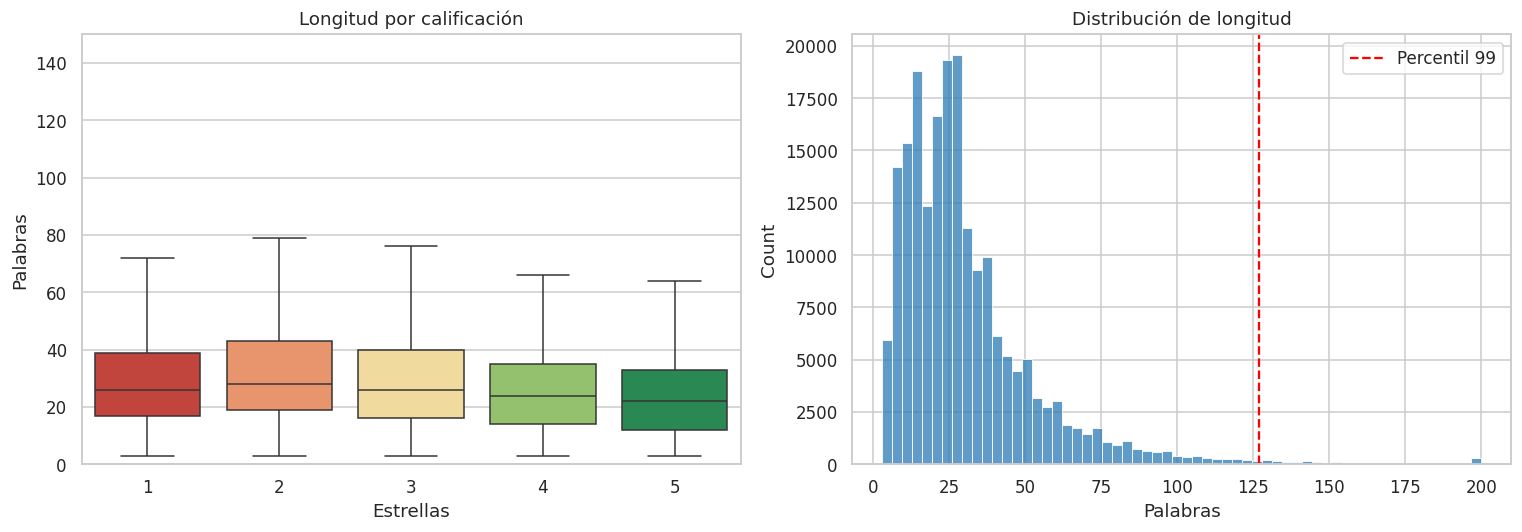

In [39]:
length_stats = train_df[["n_chars", "n_words"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)
display(length_stats)

by_star = train_df.groupby("stars")["n_words"].agg(["mean", "median", "max"]).round(1)
display(by_star)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train_df, x="stars", y="n_words", showfliers=False, palette=STAR_COLORS, ax=axes[0])
axes[0].set_ylim(0, 150)
axes[0].set_title("Longitud por calificación")
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Palabras")

sns.histplot(train_df["n_words"].clip(upper=200), bins=60, color="#2c7bb6", ax=axes[1])
axes[1].axvline(train_df["n_words"].quantile(0.99), color="red", linestyle="--", label="Percentil 99")
axes[1].set_title("Distribución de longitud")
axes[1].set_xlabel("Palabras")
axes[1].legend()

plt.tight_layout()
plt.show()

Estas tablas y gráficas representan el análisis de la longitud de los textos (cuántas palabras escribe la gente). Si miramos la tabla por estrellas y la comparamos con la gráfica de cajas y bigotes vemos lo siguiente:
- **5 estrellas (los más cortos):** tienen la mediana más baja. Cuando a alguien le gusta un producto, no necesita dar explicaciones. Solo escribe "Excelente producto, llegó a tiempo, recomendado" y listo.
- **2 estrellas (las más largas):** tienen la mediana (28) y la media (35) más altas; 1 y 3 estrellas les siguen con mediana de 26. La gente que da calificaciones intermedias o malas suele escribir mucho más para justificar su enojo o dar detalles mixtos: "El material se siente de buena calidad, pero la caja llegó aplastada, además el manual viene en chino…".

**¿Por qué importa esto para el Transformer?** El costo de la atención crece con el **cuadrado** de la longitud. Como la gran mayoría de reseñas son cortas, no tiene sentido rellenar todas hasta el máximo: en la sección 7 usamos relleno dinámico para aprovechar esto.

In [40]:
MAX_LENGTH = 128
length_percentiles = np.percentile(train_df["n_words"], [50, 75, 90, 95, 99])
coverage = (train_df["n_words"] <= MAX_LENGTH).mean()

for percentile, value in zip([50, 75, 90, 95, 99], length_percentiles):
    print(f"P{percentile}: {value:.0f} tokens")
print(f"Cobertura con MAX_LENGTH={MAX_LENGTH}: {coverage:.2%}")

P50: 25 tokens
P75: 38 tokens
P90: 59 tokens
P95: 76 tokens
P99: 127 tokens
Cobertura con MAX_LENGTH=128: 99.05%


Para la **LSTM** cortamos en **128 palabras** (el 99% cabe completo); **TF-IDF** usa el texto completo. Para el Transformer el límite se calcula en **subpalabras** (sección 5.2), porque una palabra puede partirse en varias piezas.

### 4.3 Título y cuerpo: ¿dónde está el sentimiento?

Al revisar los textos notamos que cada reseña tiene la forma `título + "\n\n" + cuerpo`, por ejemplo *"Devuelto\n\nLlega tarde y con la talla equivocada"*. El título suele ser un **resumen express** del sentimiento ("Excelente", "No lo compren", "Cumple"), así que vale la pena mirarlo por separado.

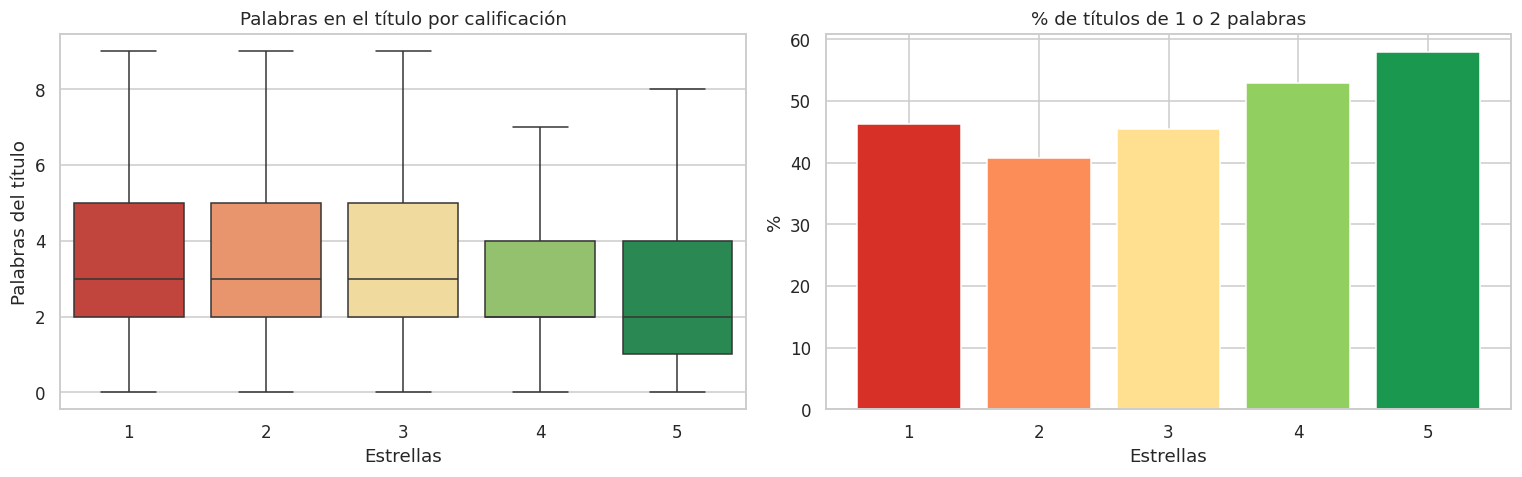

,Títulos más repetidos
stars,
1,"mala calidad, no funciona, fatal, no lo recomiendo, mal, malo"
2,"regular, mala calidad, decepción, no lo recomiendo, no es lo que esperaba, decepcionante"
3,"bien, regular, correcto, aceptable, bueno, no está mal"
4,"bien, buen producto, buena compra, perfecto, correcto, bueno"
5,"perfecto, genial, buen producto, buena compra, buena calidad, muy bien"


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=train_df, x="stars", y="title_words", showfliers=False, palette=STAR_COLORS, ax=axes[0])
axes[0].set_title("Palabras en el título por calificación")
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Palabras del título")

short_title_share = (
    train_df.assign(titulo_corto=train_df["title_words"] <= 2)
    .groupby("stars")["titulo_corto"].mean() * 100
)
axes[1].bar(short_title_share.index.astype(str), short_title_share.values, color=STAR_COLORS)
axes[1].set_title("% de títulos de 1 o 2 palabras")
axes[1].set_xlabel("Estrellas")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()

top_titles = (
    train_df.assign(title_norm=train_df["title"].str.lower().str.strip(" .!¡"))
    .groupby("stars")["title_norm"]
    .agg(lambda titles: ", ".join(titles.value_counts().head(6).index))
    .rename("Títulos más repetidos")
)
display(top_titles.to_frame())

Si bien los títulos pueden dar mucha información, notamos que no es tan claro a cual categoría puede pertenecer, vemos que en 1 y 2 estrellas se repiten titulos, de igual forma en 4 y 5 estrellas. Para validar más a profundidad realizaremos un experimento.

**Experimento rápido: ¿cuánto sabe el título solo?** Entrenamos una regresión logística con TF-IDF (misma configuración del baseline) usando solo el título, solo el cuerpo o el texto completo. Para que sea rápido usamos una muestra de 50 mil reseñas y medimos en validación sobre el experimento de 5 estrellas.

In [42]:
def make_tfidf(max_features=30_000):
    return TfidfVectorizer(
        tokenizer=simple_tokenizer,
        token_pattern=None,
        lowercase=False,
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
    )


probe_train = train_df.sample(min(50_000, len(train_df)), random_state=SEED)
probe_rows = []
for field, label in [("title", "Solo título"), ("body", "Solo cuerpo"), ("text", "Título + cuerpo")]:
    probe_pipeline = Pipeline([
        ("tfidf", make_tfidf()),
        ("classifier", LogisticRegression(max_iter=1_000, C=2.0, random_state=SEED)),
    ])
    probe_pipeline.fit(probe_train[field], probe_train["label"])
    probe_prediction = probe_pipeline.predict(val_df[field])
    probe_rows.append({
        "entrada": label,
        "val_accuracy": accuracy_score(val_df["label"], probe_prediction),
        "val_macro_f1": f1_score(val_df["label"], probe_prediction, average="macro"),
    })

probe_df = pd.DataFrame(probe_rows)
display(probe_df.style.format({"val_accuracy": "{:.4f}", "val_macro_f1": "{:.4f}"}))

title_f1 = probe_df.loc[probe_df["entrada"] == "Solo título", "val_macro_f1"].iloc[0]
full_f1 = probe_df.loc[probe_df["entrada"] == "Título + cuerpo", "val_macro_f1"].iloc[0]
hallazgo(
    f"Con solo el título (unas pocas palabras) se alcanza un macro-F1 de {title_f1:.3f}, "
    f"es decir, el {title_f1 / full_f1:.0%} de lo que se logra con el texto completo ({full_f1:.3f}). "
    "El título concentra mucha señal y está siempre al inicio de la secuencia, "
    "así que mantenemos el texto completo sin separarlo."
)

,entrada,val_accuracy,val_macro_f1
0,Solo título,0.4650,0.4639
1,Solo cuerpo,0.5108,0.5088
2,Título + cuerpo,0.5326,0.5315


> 🔎 **Hallazgo:** Con solo el título (unas pocas palabras) se alcanza un macro-F1 de 0.464, es decir, el 87% de lo que se logra con el texto completo (0.532). El título concentra mucha señal y está siempre al inicio de la secuencia, así que mantenemos el texto completo sin separarlo.

### 4.4 Señales de estilo: gritos, exclamaciones y emojis

Además de *qué* se dice, importa *cómo* se dice. Un cliente furioso suele ESCRIBIR EN MAYÚSCULAS o usar muchos signos de exclamación. Medimos qué porcentaje de reseñas de cada estrella usa cada recurso.

Esto también justifica una decisión de diseño: TF-IDF y LSTM pasan todo a minúsculas (pierden las mayúsculas), mientras que el tokenizador BPE del Transformer **conserva mayúsculas, signos y emojis**.

In [ ]:
EMOJI_PATTERN = r"[\U0001F300-\U0001FAFF\u2600-\u27BF]"
letters = train_df["text"].str.count(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]")
uppercase = train_df["text"].str.count(r"[A-ZÁÉÍÓÚÜÑ]")
upper_ratio = uppercase / letters.clip(lower=1)

style_flags = pd.DataFrame({
    "stars": train_df["stars"],
    "Usa '!'": train_df["text"].str.contains("!", regex=False),
    "Usa '?' o '¿'": train_df["text"].str.contains(r"[?¿]", regex=True),
    "Usa '...'": train_df["text"].str.contains("...", regex=False),
    "Usa emojis": train_df["text"].str.contains(EMOJI_PATTERN, regex=True),
    "Escribe en MAYÚSCULAS": (upper_ratio > 0.5) & (letters >= 10),
    "Menciona números": train_df["text"].str.contains(r"\d", regex=True),
})
style_by_star = style_flags.groupby("stars").mean() * 100

plt.figure(figsize=(10, 4.5))
sns.heatmap(style_by_star.T, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "% de reseñas"})
plt.title("Señales de estilo por calificación (% de reseñas)")
plt.xlabel("Estrellas")
plt.ylabel("")
plt.tight_layout()
plt.show()

CAPS_COL, EXCLAIM_COL, NUMBERS_COL = "Escribe en MAYÚSCULAS", "Usa '!'", "Menciona números"
caps_star = style_by_star[CAPS_COL].idxmax()
exclaim_star = style_by_star[EXCLAIM_COL].idxmax()
numbers_star = style_by_star[NUMBERS_COL].idxmax()
hallazgo(
    f"Las reseñas escritas en mayúsculas son más frecuentes en **{caps_star} estrella(s)** "
    f"({style_by_star.loc[caps_star, CAPS_COL]:.1f}%) y el '!' en **{exclaim_star} estrella(s)** "
    f"({style_by_star.loc[exclaim_star, EXCLAIM_COL]:.1f}%). "
    f"Los números aparecen más en **{numbers_star} estrella(s)**, típicamente para contar detalles "
    "(\"a los 2 días\", \"pagué 30 euros\")."
)

Los puntos suspensivos y la mención de números son las señales más asociadas a calificaciones negativas. El '?' también se inclina a lo negativo, pero es poco frecuente (<3%). El '!' se concentra en los extremos (1 y 5 estrellas), así que marca intensidad más que polaridad. Emojis y mayúsculas sostenidas son muy raros (≤1,4%) y casi no discriminan.

### 4.5 ¿Cuáles son las palabras estrella? (Ley de Zipf)

Como pasa siempre al hablar, usamos mucho palabras como "el", "la", "de", pero esas no nos dicen si alguien está feliz o enojado. Antes de buscar las palabras que sí marcan la diferencia, contamos todas las palabras del conjunto de entrenamiento (por estrella) en una sola pasada; estos conteos se reutilizan más adelante para construir el vocabulario.

In [ ]:
star_counters = {star: Counter() for star in range(5)}
for text, label in tqdm(zip(train_df["text"], train_df["label"]), total=len(train_df), desc="Contando palabras"):
    star_counters[label].update(simple_tokenizer(text))

token_counts = Counter()
for counter in star_counters.values():
    token_counts.update(counter)

frequencies = np.array(sorted(token_counts.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)
top_words = token_counts.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].loglog(ranks, frequencies, color="#2c7bb6", label="Observado")
axes[0].loglog(ranks, frequencies[0] / ranks, color="gray", linestyle="--", label="Zipf ideal (1/rango)")
axes[0].axvline(30_000, color="red", linestyle=":", label="Corte de vocabulario (30k)")
axes[0].set_title("Ley de Zipf")
axes[0].set_xlabel("Rango (log)")
axes[0].set_ylabel("Frecuencia (log)")
axes[0].legend()

words, counts = zip(*top_words)
axes[1].barh(list(words)[::-1], list(counts)[::-1], color="#2c7bb6")
axes[1].set_title("20 palabras más frecuentes")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

total_tokens = frequencies.sum()
coverage_30k = frequencies[:30_000].sum() / total_tokens
hapax_share = np.mean(frequencies == 1)
hallazgo(
    f"Hay {len(frequencies):,} palabras distintas en {total_tokens:,} apariciones. "
    f"El {hapax_share:.0%} de las palabras distintas aparece **una sola vez** (errores de tipeo, nombres de productos, palabras raras), "
    f"pero las 30.000 más frecuentes cubren el {coverage_30k:.2%} de todo el texto."
)

La gráfica de la izquierda casi forma una **línea recta** en escala logarítmica, que es justamente lo que predice la Ley de Zipf: unas pocas palabras se usan muchísimo y hay una "cola larga" enorme de palabras que casi nadie usa. Esto tiene dos consecuencias para el modelado:

1. Un vocabulario de palabras de 30 mil entradas cubre casi todo el texto, pero **todo lo que queda en la cola se vuelve `[UNK]`** para la LSTM.
2. Esa cola larga es la motivación de la **tokenización por subpalabras** (BPE) del Transformer: en lugar de descartar las palabras raras, las arma con pedacitos conocidos.

En la derecha confirmamos que las palabras más frecuentes son de relleno gramatical... con una excepción importante: **"no"** aparece entre las más usadas. Por eso, aunque quitamos stopwords para las gráficas, **nunca quitamos "no" al entrenar**. ¡Imagínate lo que pasaría si el modelo lee "funciona" en lugar de "no funciona"!

### 4.6 Palabras características de cada estrella

Primero realizaremos la comparación entre 1 estrella vs 5 estrellas.

In [ ]:
STOPWORDS_EDA = {
    "de", "la", "el", "en", "y", "a", "que", "es", "se", "del", "las", "los",
    "un", "una", "con", "por", "para", "lo", "le", "más", "pero", "mi", "me",
    "como", "muy", "al", "este", "esta", "su", "sus", "también", "si", "fue",
    "ha", "hay", "era", "ser", "he", "nos", "ya", "todo", "cuando", "bien",
    "solo", "estar", "tiene", "cada", "así", "hasta", "porque", "desde", "sobre"
}


def content_counter(counter):
    return Counter({
        word: count for word, count in counter.items()
        if word not in STOPWORDS_EDA and len(word) > 3 and not word.isdigit()
    })


negative_counter = content_counter(star_counters[0])
positive_counter = content_counter(star_counters[4])


def discriminative_words(source, comparison, n=15, min_count=30):
    source_total = sum(source.values())
    comparison_total = sum(comparison.values())
    scores = {
        word: (count / source_total + 1e-6) / (comparison[word] / comparison_total + 1e-6)
        for word, count in source.items()
        if count >= min_count
    }
    return sorted(scores.items(), key=lambda item: item[1], reverse=True)[:n]


extreme_words = {
    "Característico de 1 estrella": discriminative_words(negative_counter, positive_counter),
    "Característico de 5 estrellas": discriminative_words(positive_counter, negative_counter),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, values), color in zip(axes, extreme_words.items(), [STAR_COLORS[0], STAR_COLORS[4]]):
    words, scores = zip(*values)
    ax.barh(list(words)[::-1], list(scores)[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Ratio de frecuencia relativa (escala log)")
    ax.set_xscale("log")
plt.tight_layout()
plt.show()

Los extremos son fáciles: palabras de engaño y mala calidad para 1 estrella (timo, engaño, estafa, pésima) y de entusiasmo para 5 (magnífico, acierto, estupendos, encantada); palabras de encanto y recomendación para 5. Sin embargo, en la entrega 1 identificamos que a los modelos les cuesta identificar **2, 3 y 4 estrellas**. Así que ahora buscamos las palabras características de **cada** estrella frente al resto.

Para eso usamos el **log-odds ratio con prior informativo** (Monroe, Colaresi y Quinn, 2008, *"Fightin' Words"*). A diferencia del ratio simple, este método castiga a las palabras con pocos conteos, así que no se llena de palabras raras. El mapa de calor muestra, para cada palabra, **en qué estrella se concentra** su uso (cada fila suma 100%).

In [ ]:
content_vocab = [
    word for word, count in token_counts.items()
    if count >= 50 and word not in STOPWORDS_EDA and len(word) > 2 and not word.isdigit()
]
count_matrix = pd.DataFrame(
    {STAR_NAMES[star]: [star_counters[star][word] for word in content_vocab] for star in range(5)},
    index=content_vocab,
)
prior = count_matrix.sum(axis=1)
prior = prior / prior.sum() * 500  # prior de Dirichlet proporcional a la frecuencia global


def fightin_words(star_name):
    c_star = count_matrix[star_name]
    c_rest = count_matrix.drop(columns=star_name).sum(axis=1)
    n_star, n_rest, a0 = c_star.sum(), c_rest.sum(), prior.sum()
    log_odds_star = np.log((c_star + prior) / (n_star + a0 - c_star - prior))
    log_odds_rest = np.log((c_rest + prior) / (n_rest + a0 - c_rest - prior))
    variance = 1 / (c_star + prior) + 1 / (c_rest + prior)
    return ((log_odds_star - log_odds_rest) / np.sqrt(variance)).sort_values(ascending=False)


WORDS_PER_STAR = 7
fightin_scores = {star_name: fightin_words(star_name) for star_name in STAR_NAMES}
selected_words = []
for star_name in STAR_NAMES:
    added = 0
    for word in fightin_scores[star_name].index:
        if word not in selected_words:
            selected_words.append(word)
            added += 1
        if added == WORDS_PER_STAR:
            break

relative_freq = count_matrix.div(count_matrix.sum(axis=0), axis=1)
concentration = relative_freq.loc[selected_words]
concentration = concentration.div(concentration.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 11))
sns.heatmap(concentration, annot=True, fmt=".0f", cmap="RdYlGn_r", cbar_kws={"label": "% del uso de la palabra"})
plt.title("¿En qué estrella se concentra cada palabra?\n(palabras más características por estrella)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

middle_words = {star: ", ".join(fightin_scores[STAR_NAMES[star]].index[:6]) for star in [1, 2, 3]}
hallazgo(
    f"Palabras más características de **2 estrellas**: {middle_words[1]}. "
    f"De **3 estrellas**: {middle_words[2]}. De **4 estrellas**: {middle_words[3]}. "
    "Las estrellas intermedias se describen con palabras de matiz y no con palabras de emoción fuerte."
)

En este mapa podemos identificar que las filas de las estrellas extremas se ven muy "concentradas" (un solo color intenso), mientras que las palabras típicas de 2, 3 y 4 estrellas **se reparten entre estrellas vecinas**. Esa es la razón lingüística de que los modelos confundan estrellas adyacentes: las palabras de "más o menos", "esperaba más" o "cumple" no pertenecen a una sola calificación.

### 4.7 Negaciones y contrastes

Ya se mencionó que la palabra **"no"** es clave, pero no lo habíamos medido. Ahora contamos en qué porcentaje de reseñas de cada estrella aparecen expresiones de **negación** ("no funciona", "no está mal") y de **contraste** ("pero", "aunque"). Estas son justamente las construcciones donde esperamos que la atención del Transformer ayude, porque el significado depende de la relación entre palabras.

In [ ]:
KEY_EXPRESSIONS = {
    "no funciona": r"\bno funciona",
    "no lo recomiendo": r"\bno (?:lo|la|los|las) recomiendo",
    "lo recomiendo (sin 'no')": r"(?<!no )\b(?:lo|la|los|las) recomiendo",
    "no está mal": r"\bno est[aá] mal",
    "no es lo que esperaba": r"\bno (?:es|era) lo que esperaba",
    "pero": r"\bpero\b",
    "aunque": r"\baunque\b",
    "sin embargo": r"\bsin embargo\b",
    "relación calidad-precio": r"calidad[\s\-/]*precio",
    "por el precio": r"\bpor (?:el|ese|este) precio",
    "cumple": r"\bcumple\b",
    "devolver / devolución": r"\bdevol",
}

expression_share = pd.DataFrame({
    name: train_df["text_lower"].str.contains(pattern, regex=True).groupby(train_df["stars"]).mean() * 100
    for name, pattern in KEY_EXPRESSIONS.items()
}).T

plt.figure(figsize=(9, 6.5))
sns.heatmap(expression_share, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% de reseñas"})
plt.title("Expresiones de negación y contraste por calificación")
plt.xlabel("Estrellas")
plt.ylabel("")
plt.tight_layout()
plt.show()

contrast_peak = expression_share.loc["pero"].idxmax()
hallazgo(
    f"El conector **\"pero\"** alcanza su máximo en **{contrast_peak} estrella(s)** "
    f"({expression_share.loc['pero', contrast_peak]:.1f}% de las reseñas, frente a "
    f"{expression_share.loc['pero', 5]:.1f}% en 5 estrellas). "
    f"\"No está mal\" se concentra en {expression_share.loc['no está mal'].idxmax()} estrella(s): "
    "una negación que en realidad expresa una opinión tibia-positiva."
)

Aquí se ve claramente por qué un modelo de "bolsa de palabras" sufre: **"mal"** es una palabra negativa, pero **"no está mal"** es una opinión aceptable; **"lo recomiendo"** y **"no lo recomiendo"** comparten casi todas sus palabras. Y el "pero" aparece mucho en las reseñas intermedias, donde el cliente mezcla lo bueno con lo malo. TF-IDF con bigramas captura parte de esto; la hipótesis es que la atención lo captura mejor (lo revisamos en la sección 14.4).

### 4.8 ¿Qué tan parecidas son las estrellas entre sí?

Representamos cada estrella como un vector con la frecuencia relativa de sus palabras de contenido y calculamos la **similitud coseno** entre ellas. Si el lenguaje de 3 estrellas se parece mucho al de 2 y 4, esperamos que los modelos las confundan.

In [ ]:
star_similarity = pd.DataFrame(
    cosine_similarity(relative_freq.T.values),
    index=STAR_NAMES,
    columns=STAR_NAMES,
)

plt.figure(figsize=(7, 5.5))
off_diagonal = star_similarity.values[~np.eye(5, dtype=bool)]
sns.heatmap(star_similarity, annot=True, fmt=".3f", cmap="mako_r", vmin=off_diagonal.min(), vmax=1)
plt.title("Similitud léxica entre estrellas (coseno)")
plt.tight_layout()
plt.show()

adjacent = np.mean([star_similarity.iloc[i, i + 1] for i in range(4)])
extremes = star_similarity.iloc[0, 4]
hallazgo(
    f"La similitud promedio entre estrellas **vecinas** es {adjacent:.3f}, mientras que entre 1 y 5 estrellas es {extremes:.3f}. "
    "El vocabulario cambia de forma gradual: el problema tiene una naturaleza **ordinal**, "
    "y por eso medimos también el MAE y los errores a una estrella de distancia."
)

### 4.9 ¿Todas las reseñas están en español?

En la entrega 1 aparecieron palabras como 'bad' o 'it' entre los vecinos de los embeddings, lo que sugiere que se colaron algunas reseñas en inglés. Usamos una heurística sencilla: contamos palabras funcionales muy frecuentes de cada idioma.

In [ ]:
ENGLISH_MARKERS = {"the", "and", "is", "it", "this", "with", "for", "was", "very", "good", "not", "but", "my", "you", "they"}
SPANISH_MARKERS = {"el", "la", "de", "que", "y", "es", "en", "no", "muy", "lo", "para", "con", "pero", "se", "los"}


def looks_english(text):
    tokens = simple_tokenizer(text)
    english_hits = sum(token in ENGLISH_MARKERS for token in tokens)
    spanish_hits = sum(token in SPANISH_MARKERS for token in tokens)
    return english_hits >= 3 and english_hits > 2 * spanish_hits


train_df["looks_english"] = train_df["text"].map(looks_english)
english_share = train_df["looks_english"].mean()
print(f"Reseñas que parecen estar en inglés: {train_df['looks_english'].sum():,} ({english_share:.2%})")
display(train_df.loc[train_df["looks_english"], ["stars", "text"]].head(6))
hallazgo(
    f"Solo 1 reseña parece estar en inglés (y solo su título lo está); el dataset está prácticamente libre de otros idiomas. Es un ruido pequeño, así que **no las eliminamos**: "
    "el tokenizador BPE puede representarlas sin problema y así el modelo es más robusto a lo que realmente llega a la tienda."
)

### 4.10 Ruido en las etiquetas

Como las estrellas son una **aproximación** al sentimiento, hay reseñas donde el texto y la calificación no coinciden. Buscamos reseñas con palabras claramente positivas (y ninguna negativa) que tienen 1 estrella, y al revés. Esto nos da una idea del "techo" que ningún modelo puede superar.

In [ ]:
POSITIVE_MARKERS = {"excelente", "perfecto", "perfecta", "encanta", "encantado", "genial", "maravilla", "recomendable"}
NEGATIVE_MARKERS = {"horrible", "pésimo", "pésima", "pesimo", "basura", "estafa", "fatal", "timo"}

token_sets = train_df["text"].map(lambda text: set(simple_tokenizer(text)))
only_positive = token_sets.map(lambda tokens: bool(tokens & POSITIVE_MARKERS) and not tokens & NEGATIVE_MARKERS)
only_negative = token_sets.map(lambda tokens: bool(tokens & NEGATIVE_MARKERS) and not tokens & POSITIVE_MARKERS)

noise_table = pd.DataFrame({
    "Solo palabras positivas": only_positive.groupby(train_df["stars"]).mean() * 100,
    "Solo palabras negativas": only_negative.groupby(train_df["stars"]).mean() * 100,
})
display(noise_table.style.format("{:.2f}%"))

suspicious_positive = train_df[only_positive & (train_df["stars"] == 1)]
suspicious_negative = train_df[only_negative & (train_df["stars"] == 5)]
print(f"Reseñas de 1 estrella con lenguaje solo positivo: {len(suspicious_positive):,}")
display(suspicious_positive[["stars", "text"]].sample(min(5, len(suspicious_positive)), random_state=SEED))
print(f"Reseñas de 5 estrellas con lenguaje solo negativo: {len(suspicious_negative):,}")
display(suspicious_negative[["stars", "text"]].sample(min(5, len(suspicious_negative)), random_state=SEED))

Al leer estos ejemplos aparecen tres tipos de casos:
- **Negación de lo positivo:** "nada recomendable" "recomendable" cuenta como positivo aunque esté negado, así que el conteo de 1.316 sobrestima el ruido.
- **Contraste temporal:** "todo perfecto. No obstante…".
- **Ambigüedad léxica y errores del usuario:** En 5★, "basura" y "estafa" usadas en sentido literal ("bolsas para la basura", "ya sufrí una estafa").

Los dos primeros son difíciles pero aprendibles (¡otra vez el contexto!). El tercero es ruido puro: **ningún modelo puede acertarlos**, y esto pone un techo a las métricas que podemos esperar.

### 4.11 Viendo si spaCy entiende nuestro español

Probamos un modelo de lenguaje de spaCy (`es_core_news_md`) que ya viene "pre-entrenado" leyendo noticias en español. Queríamos ver qué tan bien se defiende leyendo reseñas de productos de Amazon (que tienen jerga, errores ortográficos y un lenguaje mucho más informal que una noticia).

In [ ]:
nlp = spacy.load("es_core_news_md")
print(f"Matriz de vectores spaCy: {nlp.vocab.vectors.shape}")

domain_words = [
    "excelente", "bueno", "perfecto", "recomendable",
    "regular", "malo", "pésimo", "terrible", "defectuoso",
    "calidad", "precio", "funciona",
]
available_words = [word for word in domain_words if nlp.vocab[word].has_vector]
vectors = {word: nlp.vocab[word].vector for word in available_words}
similarity_matrix = np.array([
    [1 - cosine(vectors[first], vectors[second]) for second in available_words]
    for first in available_words
])

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=available_words,
    yticklabels=available_words,
    cmap="RdYlGn",
    vmin=-0.1,
    vmax=1,
)
plt.title("Similitud coseno en el dominio de reseñas (spaCy)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Esta gráfica de calor nos muestra cómo el "cerebro" genérico de este modelo agrupa las palabras, revelando un problema que justifica este proyecto: aunque el modelo logra asociar sinónimos como "excelente" y "perfecto", comete el error de creer que **"bueno" y "malo" son muy parecidos**. Esto ocurre porque estos vectores se aprenden a partir del contexto ("el producto es muy bueno" vs "el producto es muy malo"): entienden la estructura gramatical, pero son ciegos a la polaridad emocional. Es precisamente por esto que entrenamos nuestros propios embeddings, dentro de la tarea de clasificación, para que el modelo aprenda que en el mundo de Amazon "bueno" y "malo" son opuestos.

In [ ]:
sample_texts = train_df["text"].sample(500, random_state=SEED).tolist()
total_alpha = 0
out_of_vocabulary = 0
oov_examples = []

for document in nlp.pipe(sample_texts, disable=["parser", "ner"]):
    for token in document:
        if token.is_alpha:
            total_alpha += 1
            if token.is_oov:
                out_of_vocabulary += 1
                if len(oov_examples) < 20:
                    oov_examples.append(token.text)

print(f"Tokens alfabéticos: {total_alpha:,}")
print(f"Tasa OOV de spaCy: {out_of_vocabulary / max(total_alpha, 1):.2%}")
print("Ejemplos OOV:", sorted(set(oov_examples))[:15])

emoji_document = nlp("Son una 💩 y no las recomiendo")
display(pd.DataFrame([
    {
        "token": token.text,
        "tiene_vector": token.has_vector,
        "es_OOV": token.is_oov,
        "norma": token.vector_norm,
    }
    for token in emoji_document
]))

La tasa de palabras desconocidas (OOV) de spaCy es baja, pero los ejemplos muestran justamente el tipo de palabras que aparecen en reseñas: errores ortográficos ("despositivo", "durarero"), mayúsculas sostenidas ("MALISIMO", "CORRESPONDEN") y formas coloquiales ("Normalito"). En la sección 5.2 veremos cómo el tokenizador por subpalabras maneja estos casos sin necesidad de un token `[UNK]`.

### 4.12 Resumen del EDA: de los hallazgos a las decisiones

| Hallazgo | Decisión de modelado |
|---|---|
| 5 clases balanceadas; 3 sentimientos en proporción 2:1:2 | Pesos por clase en la pérdida y macro-F1 como métrica principal |
| El 99% de reseñas tiene ≤ 127 palabras, pero la mediana es ~25 | Truncar al P99 y usar **relleno dinámico + bucketing** |
| Texto = título + cuerpo; el título solo ya predice bastante | Mantener el texto completo; el título queda al inicio de la secuencia |
| El '!' marca las calificaciones extremas; los '...' y los números, las negativas; emojis y mayúsculas son raros | Tokenizador BPE a nivel de bytes que **conserva** mayúsculas, signos y emojis |
| Cola larga de Zipf con muchas palabras raras y errores | Subpalabras BPE (sin `[UNK]`) para el Transformer |
| Estrellas vecinas comparten vocabulario | Esperar errores adyacentes; reportar MAE y *within-one* |
| Negaciones y contrastes cambian el sentido | Modelo con atención; análisis específico de reseñas con "pero/aunque" |
| Hay ruido en las etiquetas y prácticamente no hay reseñas en otros idiomas | Conservar la reseña con solo el título en inglés |
| spaCy confunde "bueno" con "malo" | Entrenar embeddings propios dentro de la tarea |

## 5. Desarmando las frases (Tokenización)

En esta entrega usamos **dos formas de tokenizar**, una para cada familia de modelos:

| | Por palabras | Por subpalabras BPE |
|---|---|---|
| Lo usan | TF-IDF y LSTM | Transformer |
| Unidad | Palabra completa en minúsculas | Pedazos de palabra aprendidos de las reseñas |
| Palabras desconocidas | Se vuelven `[UNK]` | No existen: cualquier texto se puede armar con pedazos (incluso emojis) |
| Mayúsculas y signos | Se pierden | Se conservan |

### 5.1 Tokenización por palabras (para la LSTM)

Aquí le enseñamos al modelo a leer: separamos cada reseña en palabras sueltas en minúsculas. Por ejemplo:
```text
"¡El producto funciona muy bien!"  -->  ["el", "producto", "funciona", "muy", "bien"]
```
Como tenemos bastantes reseñas decidimos tomar un vocabulario de **30.000 palabras** (el mismo tamaño que usaremos para el vocabulario BPE, así la comparación es justa). Reutilizamos los conteos de la sección 4.5, que se calcularon **solo con el conjunto de entrenamiento**.

In [ ]:
MAX_VOCAB = 30_000

vocabulary = {"[PAD]": 0, "[UNK]": 1}
for token, _ in token_counts.most_common(MAX_VOCAB - 2):
    vocabulary[token] = len(vocabulary)
id_to_token = {index: token for token, index in vocabulary.items()}
WORD_PAD_ID = vocabulary["[PAD]"]
WORD_UNK_ID = vocabulary["[UNK]"]


def encode_words(text, max_length=MAX_LENGTH):
    """Convierte un texto en IDs de palabras (sin relleno; el relleno se hace por lote)."""
    tokens = simple_tokenizer(text) or ["[UNK]"]
    return [vocabulary.get(token, WORD_UNK_ID) for token in tokens[:max_length]]


print(f"Vocabulario: {len(vocabulary):,}")
print("Tokens más frecuentes:", token_counts.most_common(15))
print("IDs de 'El producto funciona muy bien':", encode_words("El producto funciona muy bien"))

In [ ]:
def coverage_metrics(frame):
    total_tokens = unknown_tokens = truncated_tokens = 0
    for text in frame["text"]:
        tokens = simple_tokenizer(text)
        total_tokens += len(tokens)
        unknown_tokens += sum(token not in vocabulary for token in tokens)
        truncated_tokens += max(0, len(tokens) - MAX_LENGTH)
    return {
        "tokens": total_tokens,
        "OOV": unknown_tokens / max(total_tokens, 1),
        "truncados": truncated_tokens / max(total_tokens, 1),
    }

coverage_df = pd.DataFrame({
    "Train": coverage_metrics(train_df),
    "Validación": coverage_metrics(val_df),
    "Prueba": coverage_metrics(test_df),
}).T
display(coverage_df.style.format({"tokens": "{:,.0f}", "OOV": "{:.2%}", "truncados": "{:.2%}"}))

word_sequences = {
    "train": [encode_words(text) for text in tqdm(train_df["text"], desc="Codificando train")],
    "validation": [encode_words(text) for text in val_df["text"]],
    "test": [encode_words(text) for text in test_df["text"]],
}

Fíjate que la tasa de palabras desconocidas (OOV) es algo más alta en validación y prueba (0,89–0,96% frente a 0,65%) que en entrenamiento: el vocabulario se construyó con el entrenamiento, así que cualquier palabra nueva o mal escrita en las reseñas "del futuro" se convierte en `[UNK]` y la LSTM pierde esa información. Este es el problema que la tokenización por subpalabras resuelve.

### 5.2 Tokenización por subpalabras BPE (para el Transformer)

Siguiendo el notebook de la sesión, **entrenamos nuestro propio tokenizador** partiendo de la configuración de GPT-2 (*Byte-Level BPE*). Solo reutilizamos el "molde" (reglas de pre-tokenización y el alfabeto de bytes); el vocabulario se aprende **desde cero con nuestras reseñas**.

¿Cómo funciona BPE (*Byte Pair Encoding*)? Empieza con los caracteres individuales y, una y otra vez, **fusiona el par de pedazos más frecuente** en un pedazo nuevo, hasta llegar al tamaño de vocabulario deseado. Así, las palabras frecuentes quedan como un solo token y las raras se arman con pedazos.

In [28]:
BPE_VOCAB_SIZE = 30_000
train_texts = train_df["text"].tolist()


def training_corpus(batch_size=1_000):
    for start in range(0, len(train_texts), batch_size):
        yield train_texts[start:start + batch_size]


base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
started = time.time()
bpe_tokenizer = base_tokenizer.train_new_from_iterator(
    training_corpus(),
    vocab_size=BPE_VOCAB_SIZE,
    length=math.ceil(len(train_texts) / 1_000),
    initial_alphabet=ByteLevel.alphabet(),
    new_special_tokens=["[PAD]", "[CLS]"],
)
bpe_tokenizer.pad_token = "[PAD]"
bpe_tokenizer.model_max_length = 1_000_000  # truncamos nosotros; evita advertencias de GPT-2
PAD_ID = bpe_tokenizer.convert_tokens_to_ids("[PAD]")
CLS_ID = bpe_tokenizer.convert_tokens_to_ids("[CLS]")
BPE_SPECIAL_IDS = set(bpe_tokenizer.all_special_ids) | {PAD_ID, CLS_ID}

print(f"Tokenizador entrenado en {time.time() - started:.1f} s")
print(f"Vocabulario BPE: {len(bpe_tokenizer):,} tokens | PAD={PAD_ID} | CLS={CLS_ID}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizador entrenado en 13.2 s
Vocabulario BPE: 30,000 tokens | PAD=1 | CLS=2


Exploremos el tokenizador obtenido.

In [ ]:
def show_token(token):
    return bpe_tokenizer.convert_tokens_to_string([token])

bpe_vocab = sorted(bpe_tokenizer.get_vocab().items(), key=lambda item: item[1])
print("Primeros 15 tokens:")
print([show_token(token) for token, _ in bpe_vocab[:15]])
print("15 tokens de en medio:")
print([show_token(token) for token, _ in bpe_vocab[1000:1015]])
print("Últimos 15 tokens:")
print([show_token(token) for token, _ in bpe_vocab[-15:]])

example = "¡El producto NO funciona! Me llegó rotooo 😡"
encoded = bpe_tokenizer(example, add_special_tokens=False)
print(f"\nTexto: {example}")
print("Tokens:", bpe_tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("IDs:   ", encoded["input_ids"])

Igual que en la guía, los primeros tokens son caracteres y signos; en el medio aparecen palabras completas y pedazos frecuentes; y al final quedan palabras más raras. El símbolo `Ġ` indica que el token **empieza con un espacio** (es decir, es inicio de palabra). Los caracteres extraños que aparecen en el emoji son los **bytes** con los que se representa: por eso el tokenizador nunca necesita un `[UNK]`.

Ahora comparemos directamente las dos tokenizaciones con palabras "difíciles" típicas de reseñas.

In [ ]:
probe_words = [
    "excelente", "exelente", "EXCELENTE", "buenísimo", "malísimo",
    "recomendadísimo", "funcionaaa", "decepcionante", "💩",
]
rows = []
for word in probe_words:
    word_tokens = simple_tokenizer(word)
    in_vocab = bool(word_tokens) and all(token in vocabulary for token in word_tokens)
    pieces = [show_token(token) for token in bpe_tokenizer.tokenize(" " + word)]
    rows.append({
        "palabra": word,
        "LSTM (palabras)": " ".join(word_tokens) if in_vocab else "[UNK]",
        "Transformer (BPE)": " | ".join(piece.strip() or "␣" for piece in pieces),
        "n_subpalabras": len(pieces),
    })
display(pd.DataFrame(rows))

Aquí se ve la ventaja: la LSTM pierde por completo las palabras que no estaban en su vocabulario (y el emoji ni siquiera sobrevive a la limpieza), mientras que BPE las arma con pedazos conocidos. Por ejemplo, errores frecuentes como 'exelente' aparecen tanto que ambos vocabularios los aprenden completos; la diferencia está en formas raras como 'funcionaaa' (LSTM: [UNK]; BPE: funciona | aa) o en los emojis.

#### ¿Cuántas subpalabras tiene una reseña?

El Transformer no ve palabras, ve subpalabras, así que el límite de longitud se debe calcular en esa unidad. También medimos la **fertilidad** (subpalabras por palabra).

In [ ]:
def bpe_encode(texts, batch_size=10_000):
    ids = []
    for start in tqdm(range(0, len(texts), batch_size), desc="Tokenizando BPE", leave=False):
        ids.extend(bpe_tokenizer(texts[start:start + batch_size], add_special_tokens=False)["input_ids"])
    return ids

bpe_raw = {
    "train": bpe_encode(train_df["text"].tolist()),
    "validation": bpe_encode(val_df["text"].tolist()),
    "test": bpe_encode(test_df["text"].tolist()),
}
train_df["n_bpe"] = [len(ids) for ids in bpe_raw["train"]]
val_df["n_bpe"] = [len(ids) for ids in bpe_raw["validation"]]
test_df["n_bpe"] = [len(ids) for ids in bpe_raw["test"]]

fertility = train_df["n_bpe"].sum() / train_df["n_words"].sum()
percentiles = [50, 75, 90, 95, 99]
length_comparison = pd.DataFrame({
    "Palabras": np.percentile(train_df["n_words"], percentiles),
    "Subpalabras BPE": np.percentile(train_df["n_bpe"], percentiles),
}, index=[f"P{p}" for p in percentiles]).round(0)
display(length_comparison)

# +1 por el token [CLS]; redondeamos a un múltiplo de 16 y ponemos un tope de 256.
MAX_LEN_BPE = int(min(256, math.ceil((np.percentile(train_df["n_bpe"], 99) + 1) / 16) * 16))
bpe_coverage = (train_df["n_bpe"] + 1 <= MAX_LEN_BPE).mean()

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(train_df["n_words"].clip(upper=300), bins=80, color="#2c7bb6", alpha=0.5, label="Palabras", ax=ax)
sns.histplot(train_df["n_bpe"].clip(upper=300), bins=80, color="#d7191c", alpha=0.5, label="Subpalabras BPE", ax=ax)
ax.axvline(MAX_LEN_BPE, color="black", linestyle="--", label=f"MAX_LEN_BPE = {MAX_LEN_BPE}")
ax.set_title("Longitud de las reseñas: palabras vs subpalabras")
ax.set_xlabel("Longitud")
ax.legend()
plt.tight_layout()
plt.show()

hallazgo(
    f"Cada palabra se convierte en promedio en **{fertility:.2f} subpalabras** (incluyendo signos). "
    f"Fijamos `MAX_LEN_BPE = {MAX_LEN_BPE}`, que deja completas el {bpe_coverage:.2%} de las reseñas."
)

In [ ]:
def add_cls_and_truncate(ids):
    return [CLS_ID] + ids[: MAX_LEN_BPE - 1]

bpe_sequences = {split: [add_cls_and_truncate(ids) for ids in sequences] for split, sequences in bpe_raw.items()}
print("Ejemplo de secuencia final:", bpe_sequences["train"][0][:12], "...")
print("Tokens:", bpe_tokenizer.convert_ids_to_tokens(bpe_sequences["train"][0][:12]))

## 6. Modelos Baseline

Antes de las redes neuronales, trabajaremos con modelos más sencillos (Regresión Logística y LinearSVC sobre TF-IDF con unigramas y bigramas), **ahora con las ~200 mil reseñas** para realizar la comparación con el transformer.

Como el vectorizador no depende de la etiqueta, **lo ajustamos una sola vez** y reutilizamos la matriz.

También definimos aquí las funciones de evaluación que usaremos para **todos** los modelos, para que las métricas se calculen exactamente igual.

In [ ]:
TASKS = {
    "Cinco categorías": {
        "label_column": "label",
        "class_names": STAR_NAMES,
        "num_classes": 5,
    },
    "Tres categorías": {
        "label_column": "sentiment",
        "class_names": SENTIMENT_NAMES,
        "num_classes": 3,
    },
}


def compute_metrics(task, y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ordinal = task["num_classes"] == 5
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "mae": mean_absolute_error(y_true, y_pred) if ordinal else np.nan,
        "within_one": np.mean(np.abs(y_true - y_pred) <= 1) if ordinal else np.nan,
    }


def make_result_row(task_name, model_name, family, n_train, val_pred, test_pred, seconds, parameters, epochs=np.nan):
    task = TASKS[task_name]
    target = task["label_column"]
    val_metrics = compute_metrics(task, val_df[target], val_pred)
    test_metrics = compute_metrics(task, test_df[target], test_pred)
    return {
        "tarea": task_name,
        "modelo": model_name,
        "familia": family,
        "n_train": n_train,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_mae": test_metrics["mae"],
        "within_one": test_metrics["within_one"],
        "segundos": seconds,
        "parametros": parameters,
        "epocas": epochs,
    }


RESULT_FORMATS = {
    "n_train": "{:,.0f}",
    "val_accuracy": "{:.4f}",
    "val_macro_f1": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_macro_f1": "{:.4f}",
    "test_mae": lambda value: "—" if pd.isna(value) else f"{value:.4f}",
    "within_one": lambda value: "—" if pd.isna(value) else f"{value:.2%}",
    "segundos": "{:.1f}",
    "parametros": lambda value: "—" if pd.isna(value) else f"{value:,.0f}",
    "epocas": lambda value: "—" if pd.isna(value) else f"{value:.0f}",
}

In [ ]:
classical_estimators = {
    "TF-IDF + Regresión logística": lambda: LogisticRegression(
        max_iter=1_000,
        C=2.0,
        class_weight="balanced",
        random_state=SEED,
    ),
    "TF-IDF + LinearSVC": lambda: LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=SEED,
    ),
}

print("Ajustando el vectorizador TF-IDF con todo el entrenamiento...")
started = time.time()
tfidf_vectorizer = make_tfidf()
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["text"])
X_val_tfidf = tfidf_vectorizer.transform(val_df["text"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["text"])
vectorizer_seconds = time.time() - started
print(f"Matriz TF-IDF: {X_train_tfidf.shape} en {vectorizer_seconds:.1f} s")

fitted_classical = {}
all_predictions = {}
all_probabilities = {}
result_rows = []

for task_name, task in TASKS.items():
    target = task["label_column"]
    for model_name, estimator_factory in classical_estimators.items():
        print(f"Entrenando {task_name} · {model_name}")
        classifier = estimator_factory()
        started = time.time()
        classifier.fit(X_train_tfidf, train_df[target])
        elapsed = time.time() - started + vectorizer_seconds

        key = (task_name, model_name)
        fitted_classical[key] = classifier
        val_prediction = classifier.predict(X_val_tfidf)
        all_predictions[key] = classifier.predict(X_test_tfidf)
        if hasattr(classifier, "predict_proba"):
            all_probabilities[key] = classifier.predict_proba(X_test_tfidf)
        n_parameters = classifier.coef_.size + np.size(classifier.intercept_)
        result_rows.append(make_result_row(
            task_name, model_name, "Clásico", len(train_df),
            val_prediction, all_predictions[key], elapsed, n_parameters,
        ))

classical_results_df = pd.DataFrame(result_rows)
display(classical_results_df.style.format(RESULT_FORMATS))

Comparamos contra lo que obtuvimos en la entrega 1 con solo 25 mil reseñas (valores copiados de esa entrega).

In [ ]:
ENTREGA1_REFERENCE = pd.DataFrame([
    {"tarea": "Cinco categorías", "modelo": "TF-IDF + Regresión logística", "e1_test_accuracy": 0.5308, "e1_test_macro_f1": 0.5292},
    {"tarea": "Cinco categorías", "modelo": "TF-IDF + LinearSVC", "e1_test_accuracy": 0.5022, "e1_test_macro_f1": 0.4993},
    {"tarea": "Cinco categorías", "modelo": "LSTM_base", "e1_test_accuracy": 0.5238, "e1_test_macro_f1": 0.5177},
    {"tarea": "Cinco categorías", "modelo": "BiLSTM_regularizada", "e1_test_accuracy": 0.5308, "e1_test_macro_f1": 0.5287},
    {"tarea": "Tres categorías", "modelo": "TF-IDF + Regresión logística", "e1_test_accuracy": 0.7414, "e1_test_macro_f1": 0.7020},
    {"tarea": "Tres categorías", "modelo": "TF-IDF + LinearSVC", "e1_test_accuracy": 0.7358, "e1_test_macro_f1": 0.6805},
    {"tarea": "Tres categorías", "modelo": "LSTM_base", "e1_test_accuracy": 0.7180, "e1_test_macro_f1": 0.6866},
    {"tarea": "Tres categorías", "modelo": "BiLSTM_regularizada", "e1_test_accuracy": 0.7470, "e1_test_macro_f1": 0.7051},
])

classical_vs_e1 = classical_results_df.merge(ENTREGA1_REFERENCE, on=["tarea", "modelo"])
classical_vs_e1["cambio_macro_f1"] = classical_vs_e1["test_macro_f1"] - classical_vs_e1["e1_test_macro_f1"]
display(classical_vs_e1[["tarea", "modelo", "e1_test_macro_f1", "test_macro_f1", "cambio_macro_f1"]].style.format({
    "e1_test_macro_f1": "{:.4f}", "test_macro_f1": "{:.4f}", "cambio_macro_f1": "{:+.4f}",
}))

best_lr = classical_vs_e1[classical_vs_e1["modelo"] == "TF-IDF + Regresión logística"].set_index("tarea")
hallazgo(
    "Con 8 veces más datos, la regresión logística pasa de "
    f"{best_lr.loc['Cinco categorías', 'e1_test_macro_f1']:.4f} a {best_lr.loc['Cinco categorías', 'test_macro_f1']:.4f} "
    "de macro-F1 en 5 estrellas y de "
    f"{best_lr.loc['Tres categorías', 'e1_test_macro_f1']:.4f} a {best_lr.loc['Tres categorías', 'test_macro_f1']:.4f} en 3 sentimientos. "
    "Esta es la vara que el Transformer tiene que superar."
)

Los modelos clásicos siguen siendo muy fuertes y rápidos. Ahora el listón queda todavía más alto, porque también los modelos clásicos se benefician de tener más datos.

## 7. Empaquetando los datos para PyTorch

Las redes neuronales necesitan que todas las secuencias de un lote tengan el mismo tamaño, así que rellenamos con `[PAD]`. En la entrega 1 rellenábamos **todas** las reseñas hasta 128 posiciones. Con 200 mil reseñas y un Transformer (cuyo costo crece con el cuadrado de la longitud), eso es un desperdicio enorme, porque la mitad de las reseñas tiene menos de ~31 subpalabras (mediana).

Hacemos dos mejoras:

1. **Relleno dinámico:** cada lote se rellena solo hasta la reseña más larga **de ese lote**.
2. **Agrupación por longitud (*bucketing*):** barajamos los datos, los partimos en bloques grandes, ordenamos cada bloque por longitud y armamos los lotes. Así cada lote tiene reseñas de tamaño parecido (poco relleno), pero el orden sigue siendo aleatorio entre épocas.

Además, cada lote lleva una **máscara de atención** (1 = token real, 0 = relleno) para que el Transformer ignore el relleno, y las **longitudes reales** para que la LSTM use `pack_padded_sequence`, igual que en la entrega 1.

In [ ]:
class EncodedReviewDataset(TorchDataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.labels[index]


class PadCollator:
    """Rellena cada lote hasta la secuencia más larga del lote."""

    def __init__(self, pad_id):
        self.pad_id = pad_id

    def __call__(self, batch):
        sequences, labels = zip(*batch)
        lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
        input_ids = torch.full((len(sequences), int(lengths.max())), self.pad_id, dtype=torch.long)
        for row, sequence in enumerate(sequences):
            input_ids[row, : len(sequence)] = torch.as_tensor(sequence, dtype=torch.long)
        attention_mask = (torch.arange(input_ids.size(1))[None, :] < lengths[:, None]).long()
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "length": lengths,
            "label": torch.tensor(labels, dtype=torch.long),
        }


class BucketBatchSampler(Sampler):
    """Lotes con reseñas de longitud parecida, en orden aleatorio en cada época."""

    def __init__(self, lengths, batch_size, bucket_factor=50, seed=SEED):
        self.lengths = np.asarray(lengths)
        self.batch_size = batch_size
        self.bucket_size = batch_size * bucket_factor
        self.seed = seed
        self.epoch = 0

    def _batches(self, rng):
        indices = rng.permutation(len(self.lengths))
        batches = []
        for start in range(0, len(indices), self.bucket_size):
            bucket = indices[start:start + self.bucket_size]
            bucket = bucket[np.argsort(self.lengths[bucket], kind="stable")]
            batches.extend(bucket[i:i + self.batch_size] for i in range(0, len(bucket), self.batch_size))
        return [batches[i] for i in rng.permutation(len(batches))]

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1
        for batch in self._batches(rng):
            yield batch.tolist()

    def __len__(self):
        full, rest = divmod(len(self.lengths), self.bucket_size)
        return full * math.ceil(self.bucket_size / self.batch_size) + math.ceil(rest / self.batch_size)


BATCH_SIZE = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

TOKENIZATIONS = {
    "palabras": {"sequences": word_sequences, "pad_id": WORD_PAD_ID},
    "bpe": {"sequences": bpe_sequences, "pad_id": PAD_ID},
}


def build_loaders(tokenization, label_column, train_indices=None, batch_size=BATCH_SIZE):
    sequences = TOKENIZATIONS[tokenization]["sequences"]
    collator = PadCollator(TOKENIZATIONS[tokenization]["pad_id"])
    train_sequences = sequences["train"]
    train_labels = train_df[label_column].to_numpy()
    if train_indices is not None:
        train_sequences = [train_sequences[index] for index in train_indices]
        train_labels = train_labels[train_indices]

    loader_kwargs = {
        "collate_fn": collator,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
        "persistent_workers": NUM_WORKERS > 0,
    }
    train_sampler = BucketBatchSampler([len(sequence) for sequence in train_sequences], batch_size)
    return {
        "train": DataLoader(EncodedReviewDataset(train_sequences, train_labels), batch_sampler=train_sampler, **loader_kwargs),
        "validation": DataLoader(
            EncodedReviewDataset(sequences["validation"], val_df[label_column]),
            batch_size=batch_size, shuffle=False, **loader_kwargs,
        ),
        "test": DataLoader(
            EncodedReviewDataset(sequences["test"], test_df[label_column]),
            batch_size=batch_size, shuffle=False, **loader_kwargs,
        ),
    }


for tokenization in TOKENIZATIONS:
    batch = next(iter(build_loaders(tokenization, "label")["train"]))
    print(
        f"{tokenization:>9}: input_ids {tuple(batch['input_ids'].shape)} | "
        f"mask {tuple(batch['attention_mask'].shape)} | labels {tuple(batch['label'].shape)}"
    )

¿Cuánto nos ahorra esto? Simulamos una época completa con las tres estrategias y contamos qué porcentaje de las posiciones procesadas son relleno.

In [ ]:
def padding_share(lengths, strategy, batch_size=BATCH_SIZE):
    lengths = np.asarray(lengths)
    rng = np.random.default_rng(SEED)
    if strategy == "Fijo (entrega 1)":
        total = len(lengths) * MAX_LEN_BPE
    elif strategy == "Dinámico aleatorio":
        order = rng.permutation(len(lengths))
        total = sum(lengths[order[i:i + batch_size]].max() * len(order[i:i + batch_size]) for i in range(0, len(order), batch_size))
    else:
        sampler = BucketBatchSampler(lengths, batch_size)
        total = sum(lengths[batch].max() * len(batch) for batch in sampler._batches(rng))
    return 1 - lengths.sum() / total, total

bpe_lengths = [len(sequence) for sequence in bpe_sequences["train"]]
padding_rows = []
for strategy in ["Fijo (entrega 1)", "Dinámico aleatorio", "Dinámico + bucketing"]:
    share, total = padding_share(bpe_lengths, strategy)
    padding_rows.append({"estrategia": strategy, "% posiciones de relleno": share * 100, "posiciones procesadas": total})
padding_df = pd.DataFrame(padding_rows)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(padding_df["estrategia"], padding_df["posiciones procesadas"] / 1e6, color=["#bdbdbd", "#6baed6", "#2171b5"])
ax.bar_label(bars, labels=[f"{value:.0f}% relleno" for value in padding_df["% posiciones de relleno"]], padding=4)
ax.set_xlabel("Millones de posiciones procesadas por época")
ax.set_title("Costo de una época según la estrategia de relleno")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

saving = padding_df["posiciones procesadas"].iloc[0] / padding_df["posiciones procesadas"].iloc[2]
hallazgo(f"Con relleno dinámico y bucketing, cada época procesa **{saving:.1f} veces menos posiciones** que con relleno fijo.")

## 8. La red recurrente (LSTM)

Mantenemos la LSTM de la entrega 1 como baseline neuronal, en su versión **unidireccional** (lee el texto de izquierda a derecha). La arquitectura es la misma: embedding → LSTM → clasificador denso. Solo cambiamos la firma del `forward` para que reciba el mismo lote que el Transformer.

Usamos `pack_padded_sequence` para decirle a la red: *"Oye, ignora el relleno, concéntrate solo en las palabras reales"*.

In [ ]:
class RecurrentTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        dropout=0.2,
        pad_id=0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)
        self.embedding_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, input_ids, attention_mask=None, lengths=None):
        if lengths is None:
            lengths = attention_mask.sum(dim=1)
        embedded = self.embedding_dropout(self.embedding(input_ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        return self.classifier(hidden[-1])

## 9. El Transformer desde cero

Implementamos un **Transformer encoder** (la mitad izquierda de la arquitectura de *Attention Is All You Need*), porque para clasificar solo necesitamos *entender* el texto, no generarlo. Lo construimos pieza por pieza, basándonos en el notebook de la sesión:

```text
reseña ─► tokens BPE ─► embeddings + posición ─► [bloque encoder] × N ─► pooling ─► clasificador ─► estrellas / sentimiento
                                                  │
                                                  ├─ atención multi-cabeza + residual + LayerNorm
                                                  └─ red feed-forward      + residual + LayerNorm
```

### 9.1 Embeddings posicionales

La atención, por sí sola, **no sabe en qué orden vienen las palabras**: para ella "no es bueno, es malo" y "no es malo, es bueno" son el mismo conjunto de tokens. Por eso se le suma a cada embedding un vector que codifica su posición. Según el paper, se usan funciones seno y coseno:

$$
PE(pos, 2i) = \sin(pos/10000^{2i/d_{model}}) \\
PE(pos, 2i + 1) = \cos(pos/10000^{2i/d_{model}})
$$

Donde:
- $pos$ es la posición del *token* en la secuencia.
- $i$ es la dimensión dentro del embedding.
- $d_{model}$ es la dimensionalidad total del embedding.

Las dimensiones pares usan seno y las impares coseno, cada par con una frecuencia distinta. Como no tienen parámetros, se pre-calculan una sola vez. Los autores también mencionan que se pueden **aprender** como parte del entrenamiento con resultados similares; implementamos ambas versiones para comprobarlo en nuestras reseñas (ablación en la sección 10), y una tercera opción **sin posición** para medir cuánto importa el orden.

Siguiendo el paper, los embeddings de los tokens se multiplican por $\sqrt{d_{model}}$ antes de sumarles la posición, para que ambas señales tengan una escala comparable.

In [ ]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        # Vector columna con las posiciones (pos) y vector fila con las dimensiones (i).
        position = torch.arange(max_len).unsqueeze(1)
        dimension = torch.arange(d_model).unsqueeze(0)
        # Denominador de la fórmula: 10000^(2i / d_model)
        angle_rates = 1 / torch.pow(10000, (2 * (dimension // 2)) / d_model)
        angles = position * angle_rates

        encoding = torch.zeros(max_len, d_model)
        encoding[:, 0::2] = torch.sin(angles[:, 0::2])  # PE(pos, 2i)
        encoding[:, 1::2] = torch.cos(angles[:, 1::2])  # PE(pos, 2i + 1)
        # Buffer: se mueve con el modelo a la GPU pero no se entrena.
        self.register_buffer("encoding", encoding.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.encoding[:, : x.size(1)]


class LearnablePositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.position_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device)
        return x + self.position_embedding(positions).unsqueeze(0)


class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len, pos_encoding="sinusoidal", dropout=0.1, pad_id=0):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.scale = math.sqrt(d_model)
        if pos_encoding == "sinusoidal":
            self.position = SinusoidalPositionalEncoding(max_len, d_model)
        elif pos_encoding == "learnable":
            self.position = LearnablePositionalEncoding(max_len, d_model)
        elif pos_encoding == "none":
            self.position = nn.Identity()
        else:
            raise ValueError(f"Codificación posicional desconocida: {pos_encoding}")
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        return self.dropout(self.position(self.token_embedding(input_ids) * self.scale))

A manera exploratoria, observemos cómo son estos vectores. A la izquierda, vemos la matriz completa: las primeras dimensiones oscilan rápido y las últimas muy lento, así que cada posición recibe una "huella" única. A la derecha agregamos la **similitud coseno entre posiciones**: las posiciones cercanas se parecen más entre sí que las lejanas, lo que le permite al modelo razonar sobre distancias relativas.

In [ ]:
positional_demo = SinusoidalPositionalEncoding(MAX_LEN_BPE, 256).encoding.squeeze(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mesh = axes[0].pcolormesh(positional_demo, cmap="viridis")
axes[0].set_xlabel("Dimensión del embedding")
axes[0].set_ylabel("Posición")
axes[0].set_title("Codificación posicional sinusoidal")
fig.colorbar(mesh, ax=axes[0])

position_similarity = cosine_similarity(positional_demo)
image = axes[1].imshow(position_similarity, cmap="magma")
axes[1].set_xlabel("Posición")
axes[1].set_ylabel("Posición")
axes[1].set_title("Similitud coseno entre posiciones")
fig.colorbar(image, ax=axes[1])
plt.tight_layout()
plt.show()

### 9.2 Atención multi-cabeza

Recordemos que la atención se define como:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Intuitivamente, cada token hace una **pregunta** ($Q$), compara esa pregunta con las **etiquetas** de todos los demás tokens ($K$) y con esos puntajes mezcla su **contenido** ($V$). Dividir por $\sqrt{d_k}$ evita que los puntajes crezcan demasiado y el softmax se sature.

La atención **multi-cabeza** parte el embedding en $h$ pedazos y ejecuta esta operación en paralelo en cada uno. Así, una cabeza puede especializarse en negaciones, otra en adjetivos, otra en el título, etc. Al final se concatenan y se mezclan con una capa lineal.

**La máscara de atención:** como rellenamos con `[PAD]`, no queremos que ningún token le preste atención al relleno. Para eso, antes del softmax ponemos un número **muy negativo** en esas posiciones, así su peso queda prácticamente en cero.

In [ ]:
def scaled_dot_product_attention(q, k, v, attention_mask=None, dropout=None):
    """Atención de producto punto escalada.

    q, k, v: (batch, cabezas, longitud, d_k)
    attention_mask: (batch, longitud) con 1 = token real y 0 = relleno.
    """
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if attention_mask is not None:
        padding = attention_mask[:, None, None, :] == 0
        scores = scores.masked_fill(padding, torch.finfo(scores.dtype).min)
    weights = torch.softmax(scores, dim=-1)
    if dropout is not None:
        weights = dropout(weights)
    return torch.matmul(weights, v), weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads=8, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "El tamaño del embedding debe ser divisible por el número de cabezas"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.combine_heads = nn.Linear(d_model, d_model)
        self.attention_dropout = nn.Dropout(dropout)

    def _split_heads(self, x):
        batch_size, seq_len, _ = x.shape
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)  # (batch, L, h, d_k)
        return x.transpose(1, 2)                                         # (batch, h, L, d_k)

    def forward(self, x, attention_mask=None, return_attention=False):
        batch_size, seq_len, _ = x.shape
        q = self._split_heads(self.query(x))
        k = self._split_heads(self.key(x))
        v = self._split_heads(self.value(x))

        values, weights = scaled_dot_product_attention(q, k, v, attention_mask, self.attention_dropout)
        values = values.transpose(1, 2).reshape(batch_size, seq_len, self.d_model)  # concatenar cabezas
        output = self.combine_heads(values)
        return (output, weights) if return_attention else output

Hagamos una prueba rápida para confirmar que la máscara funciona. Tomamos una secuencia de 4 tokens reales y 4 de relleno y medimos qué fracción de la atención se va hacia el relleno.

In [ ]:
torch.manual_seed(SEED)
demo_x = torch.randn(1, 8, 64)
demo_mask = torch.tensor([[1, 1, 1, 1, 0, 0, 0, 0]])
demo_q = demo_k = demo_v = demo_x.view(1, 8, 4, 16).transpose(1, 2)

_, weights_ok = scaled_dot_product_attention(demo_q, demo_k, demo_v, demo_mask)

print(f"Atención hacia el relleno con nuestra máscara: {weights_ok[..., 4:].sum(-1).mean():.6f}")

mha_demo = MultiHeadAttention(d_model=64, num_heads=4)
print("Forma de salida de la atención multi-cabeza:", tuple(mha_demo(demo_x, demo_mask).shape))

La prueba confirma que la máscara funciona: la atención que llega a las posiciones de relleno es exactamente cero. Esto ocurre porque, antes del softmax, a esas posiciones se les asigna el valor más negativo que puede representar el tipo de dato. Así, su peso queda en cero y toda la atención se reparte entre los tokens reales. También se comprueba que la atención multi-cabeza conserva la forma de la entrada (lote, longitud, dimensión), así que el bloque puede apilarse sin problemas.

Esto es especialmente importante en nuestro caso, porque usamos relleno dinámico: la cantidad de relleno cambia de un lote a otro según la reseña más larga. Gracias a la máscara, una misma reseña obtiene la misma representación sin importar con qué otras reseñas comparta lote, y el promedio de los tokens (mean pooling) no se diluye con posiciones vacías.

### 9.3 El bloque Transformer (encoder)

Un bloque encoder combina la atención con una pequeña red *feed-forward* que procesa cada token por separado. Dos detalles son fundamentales:

- **Conexiones residuales:** se suma la entrada a la salida de cada sub-capa ($x + \text{SubCapa}(x)$). Sin ellas, la información original del token se pierde y apilar varios bloques se vuelve muy difícil de entrenar.
- **Posición de la normalización:** el paper original normaliza **después** de sumar (*Post-LN*). Trabajos posteriores (Xiong et al., 2020) mostraron que normalizar **antes** (*Pre-LN*) hace el entrenamiento más estable cuando hay varios bloques. Implementamos ambas.

```text
Post-LN (paper original)                 Pre-LN (más estable al apilar bloques)
x ─► Atención ─► (+x) ─► LayerNorm        x ─► LayerNorm ─► Atención ─► (+x)
  ─► FFN      ─► (+x) ─► LayerNorm          ─► LayerNorm ─► FFN      ─► (+x)
```

In [ ]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, norm_first=True):
        super().__init__()
        self.norm_first = norm_first
        self.attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None, return_attention=False):
        if self.norm_first:
            attended, weights = self.attention(self.norm1(x), attention_mask, return_attention=True)
            x = x + self.dropout1(attended)
            x = x + self.dropout2(self.feed_forward(self.norm2(x)))
        else:
            attended, weights = self.attention(x, attention_mask, return_attention=True)
            x = self.norm1(x + self.dropout1(attended))
            x = self.norm2(x + self.dropout2(self.feed_forward(x)))
        return (x, weights) if return_attention else x

### 9.4 El clasificador completo

El bloque encoder entrega **un vector por token**, pero necesitamos **un solo vector por reseña**. Para el clasificador utilizamos dos estrategias:

- **Promedio (mean pooling):** promediamos los vectores de los tokens reales (usando la máscara para no contar el relleno).
- **Token `[CLS]`:** usamos el vector del token especial que pusimos al inicio. Gracias a la atención, este token puede "leer" toda la reseña y funcionar como resumen (es la estrategia de BERT).

Nuestro modelo devuelve **logits** directamente.

Los pesos se inicializan con una normal de desviación 0.02, como en BERT/GPT-2.

In [ ]:
class TransformerReviewClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes,
        max_len,
        pad_id=0,
        d_model=256,
        num_heads=8,
        num_layers=2,
        ff_dim=1024,
        dropout=0.1,
        pos_encoding="sinusoidal",
        pooling="mean",
        norm_first=True,
    ):
        super().__init__()
        assert pooling in {"mean", "cls"}
        self.pooling = pooling
        self.embeddings = TokenAndPositionEmbedding(vocab_size, d_model, max_len, pos_encoding, dropout, pad_id)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, ff_dim, dropout, norm_first)
            for _ in range(num_layers)
        ])
        # Con Pre-LN la salida del último bloque no está normalizada, así que agregamos una LayerNorm final.
        self.final_norm = nn.LayerNorm(d_model) if norm_first else nn.Identity()
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.padding_idx is not None:
                with torch.no_grad():
                    module.weight[module.padding_idx].zero_()

    def encode(self, input_ids, attention_mask, return_attention=False):
        """Devuelve el vector de la reseña (y opcionalmente la atención de cada bloque)."""
        x = self.embeddings(input_ids)
        attentions = []
        for block in self.blocks:
            x, weights = block(x, attention_mask, return_attention=True)
            if return_attention:
                attentions.append(weights)
        x = self.final_norm(x)
        if self.pooling == "cls":
            pooled = x[:, 0]
        else:
            mask = attention_mask.unsqueeze(-1).to(x.dtype)
            pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        return (pooled, attentions) if return_attention else pooled

    def forward(self, input_ids, attention_mask, lengths=None):
        return self.classifier(self.encode(input_ids, attention_mask))

### 9.5 Probando las piezas con un lote real

Igual que en la guía, verificamos que las formas de los tensores sean correctas en cada etapa, esta vez con un lote real de reseñas. También contamos cuántos parámetros tiene cada parte.

In [ ]:
demo_batch = next(iter(build_loaders("bpe", "label")["train"]))
demo_model = TransformerReviewClassifier(
    vocab_size=len(bpe_tokenizer), num_classes=5, max_len=MAX_LEN_BPE, pad_id=PAD_ID,
    d_model=256, num_heads=8, num_layers=2, ff_dim=1024,
).eval()

with torch.no_grad():
    ids, mask = demo_batch["input_ids"], demo_batch["attention_mask"]
    embedded = demo_model.embeddings(ids)
    after_block = demo_model.blocks[0](embedded, mask)
    pooled = demo_model.encode(ids, mask)
    logits = demo_model(ids, mask)

print(f"input_ids:        {tuple(ids.shape)}   (batch, longitud del lote)")
print(f"embeddings:       {tuple(embedded.shape)}")
print(f"salida bloque 1:  {tuple(after_block.shape)}")
print(f"vector reseña:    {tuple(pooled.shape)}")
print(f"logits:           {tuple(logits.shape)}")


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


parameter_table = pd.Series({
    "Embeddings de tokens": count_parameters(demo_model.embeddings),
    "Bloques encoder": count_parameters(demo_model.blocks),
    "Cabeza de clasificación (pooling)": count_parameters(demo_model.classifier),
    "Total": count_parameters(demo_model),
}, name="parámetros")
display(parameter_table.to_frame().style.format("{:,.0f}"))

La mayor parte de los parámetros está en la tabla de embeddings (30.000 tokens × 256 dimensiones). Los bloques encoder, que son los que hacen el "trabajo inteligente", son relativamente livianos.

## 10. Entrenamiento

### 10.1 Un solo módulo de Lightning para todas las redes

En la entrega 1 el `LightningModule` estaba amarrado a la LSTM. Ahora lo generalizamos: recibe el tipo de arquitectura (`lstm` o `transformer`) y su configuración, y construye la red por dentro. Así **las dos familias se entrenan exactamente con el mismo ciclo**: la misma pérdida con pesos por clase, las mismas métricas, el mismo early stopping y el mismo recorte de gradientes.

La única diferencia está en el optimizador, porque los Transformers son más delicados al inicio del entrenamiento:

| | LSTM (igual que la entrega 1) | Transformer |
|---|---|---|
| Optimizador | AdamW, `lr=1e-3` | AdamW, `lr=5e-4`, sin *weight decay* en sesgos ni LayerNorm |
| Programación del *learning rate* | Se reduce a la mitad si el macro-F1 de validación se estanca | **Calentamiento lineal** (6% de los pasos) y luego **decaimiento coseno** |

¿Por qué el calentamiento? Al inicio los pesos son aleatorios y los gradientes de la atención pueden ser enormes; empezar con un *learning rate* pequeño y subirlo poco a poco evita que el modelo "se descarrile" en los primeros pasos.

In [ ]:
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")


def build_network(architecture, num_classes, network_config):
    if architecture == "lstm":
        return RecurrentTextClassifier(num_classes=num_classes, **network_config)
    if architecture == "transformer":
        return TransformerReviewClassifier(num_classes=num_classes, **network_config)
    raise ValueError(f"Arquitectura desconocida: {architecture}")


class LitReviewClassifier(L.LightningModule):
    def __init__(
        self,
        architecture,
        network_config,
        num_classes,
        class_weights,
        learning_rate=1e-3,
        weight_decay=1e-5,
        scheduler="plateau",
        warmup_ratio=0.06,
        label_smoothing=0.0,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.network = build_network(architecture, num_classes, network_config)
        self.register_buffer("loss_weights", torch.tensor(class_weights, dtype=torch.float32))

        # Accuracy micro para que sea comparable con sklearn.accuracy_score; el balance se ve con macro-F1.
        for stage in ["train", "val", "test"]:
            setattr(self, f"{stage}_accuracy", MulticlassAccuracy(num_classes=num_classes, average="micro"))
            setattr(self, f"{stage}_f1", MulticlassF1Score(num_classes=num_classes, average="macro"))

    def forward(self, batch):
        return self.network(batch["input_ids"], batch["attention_mask"], batch["length"])

    def shared_step(self, batch, stage):
        logits = self(batch).float()
        labels = batch["label"]
        loss = F.cross_entropy(
            logits, labels, weight=self.loss_weights, label_smoothing=self.hparams.label_smoothing
        )
        predictions = logits.argmax(dim=1)

        accuracy_metric = getattr(self, f"{stage}_accuracy")
        f1_metric = getattr(self, f"{stage}_f1")
        accuracy_metric(predictions, labels)
        f1_metric(predictions, labels)

        batch_size = len(labels)
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)
        self.log(f"{stage}_accuracy", accuracy_metric, on_step=False, on_epoch=True, prog_bar=False, batch_size=batch_size)
        self.log(f"{stage}_f1", f1_metric, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)
        return loss

    def training_step(self, batch, batch_idx):
        return self.shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self.shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self.shared_step(batch, "test")

    def predict_step(self, batch, batch_idx):
        probabilities = torch.softmax(self(batch).float(), dim=1)
        return {"prediction": probabilities.argmax(dim=1), "probabilities": probabilities}

    def configure_optimizers(self):
        hp = self.hparams
        if hp.scheduler == "plateau":
            optimizer = torch.optim.AdamW(self.parameters(), lr=hp.learning_rate, weight_decay=hp.weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
            return {
                "optimizer": optimizer,
                "lr_scheduler": {"scheduler": scheduler, "monitor": "val_f1"},
            }

        decay, no_decay = [], []
        for name, parameter in self.named_parameters():
            if parameter.requires_grad:
                (no_decay if parameter.ndim < 2 or "norm" in name else decay).append(parameter)
        optimizer = torch.optim.AdamW(
            [
                {"params": decay, "weight_decay": hp.weight_decay},
                {"params": no_decay, "weight_decay": 0.0},
            ],
            lr=hp.learning_rate,
            betas=(0.9, 0.98),
            eps=1e-6,
        )
        total_steps = max(1, int(self.trainer.estimated_stepping_batches))
        warmup_steps = max(1, int(total_steps * hp.warmup_ratio))

        def warmup_cosine(step):
            if step < warmup_steps:
                return (step + 1) / warmup_steps
            progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
            return 0.5 * (1.0 + math.cos(math.pi * progress))

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_cosine)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "step"},
        }

### 10.2 La función de entrenamiento

Mientras los modelos entrenan, los vigilamos de cerca: si el macro-F1 de validación deja de mejorar durante 2 épocas, detenemos el entrenamiento (*early stopping*) y nos quedamos con **la mejor época** guardada en el *checkpoint*. Con ese mejor modelo generamos las predicciones de validación y prueba y calculamos las métricas con las mismas funciones que usamos para TF-IDF.

In [ ]:
CHECKPOINT_DIR = Path("checkpoints")
LOG_DIR = Path("logs")
PRECISION = "16-mixed" if torch.cuda.is_available() else "32-true"


def get_class_weights(labels, num_classes):
    classes = np.arange(num_classes)
    return compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(labels)).tolist()


def collect_predictions(trainer, model, loader):
    batches = trainer.predict(model, dataloaders=loader)
    predictions = torch.cat([batch["prediction"].cpu() for batch in batches]).numpy()
    probabilities = torch.cat([batch["probabilities"].cpu() for batch in batches]).numpy()
    return predictions, probabilities


def train_neural(
    task_name,
    model_name,
    family,
    architecture,
    network_config,
    optim_config,
    max_epochs,
    train_indices=None,
    run_prefix="",
    keep_model=True,
):
    task = TASKS[task_name]
    target = task["label_column"]
    tokenization = "palabras" if architecture == "lstm" else "bpe"
    loaders = build_loaders(tokenization, target, train_indices)
    train_labels = train_df[target].to_numpy()
    if train_indices is not None:
        train_labels = train_labels[train_indices]

    model = LitReviewClassifier(
        architecture=architecture,
        network_config=network_config,
        num_classes=task["num_classes"],
        class_weights=get_class_weights(train_labels, task["num_classes"]),
        **optim_config,
    )

    run_name = f"{run_prefix}{task_name.replace(' ', '_')}_{model_name}"
    checkpoint = ModelCheckpoint(
        dirpath=CHECKPOINT_DIR / run_name,
        filename="{epoch:02d}-{val_f1:.4f}",
        monitor="val_f1",
        mode="max",
        save_top_k=1,
    )
    callbacks = [
        checkpoint,
        EarlyStopping(monitor="val_f1", mode="max", patience=EARLY_STOPPING_PATIENCE, min_delta=0.001),
        LearningRateMonitor(logging_interval="step"),
    ]
    csv_logger = CSVLogger(LOG_DIR, name=run_name)
    trainer = Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices=1,
        precision=PRECISION,
        callbacks=callbacks,
        logger=csv_logger,
        deterministic="warn",
        gradient_clip_val=1.0,
        log_every_n_steps=50,
        enable_model_summary=False,
        use_distributed_sampler=False,
    )

    started = time.time()
    trainer.fit(model, train_dataloaders=loaders["train"], val_dataloaders=loaders["validation"])
    elapsed = time.time() - started

    best_model = LitReviewClassifier.load_from_checkpoint(checkpoint.best_model_path)
    val_predictions, _ = collect_predictions(trainer, best_model, loaders["validation"])
    test_predictions, test_probabilities = collect_predictions(trainer, best_model, loaders["test"])
    best_epoch = int(re.search(r"epoch=(\d+)", Path(checkpoint.best_model_path).name).group(1)) + 1

    row = make_result_row(
        task_name, model_name, family, len(train_labels),
        val_predictions, test_predictions, elapsed,
        count_parameters(best_model), trainer.current_epoch,
    )
    row["mejor_epoca"] = best_epoch
    print(
        f"✔ {task_name} · {model_name}: val macro-F1 {row['val_macro_f1']:.4f} | "
        f"test macro-F1 {row['test_macro_f1']:.4f} | {elapsed / 60:.1f} min | mejor época {best_epoch}"
    )

    result = {
        "model": best_model.cpu().eval() if keep_model else None,
        "architecture": architecture,
        "tokenization": tokenization,
        "test_predictions": test_predictions,
        "test_probabilities": test_probabilities,
        "csv_path": Path(csv_logger.log_dir) / "metrics.csv",
        "checkpoint": checkpoint.best_model_path,
        "row": row,
    }
    del trainer, model
    if not keep_model:
        del best_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


RESULT_FORMATS["mejor_epoca"] = lambda value: "—" if pd.isna(value) else f"{value:.0f}"
runs = {}


def register_run(key, run):
    runs[key] = run
    all_predictions[key] = run["test_predictions"]
    all_probabilities[key] = run["test_probabilities"]
    result_rows.append(run["row"])

### 10.3 Baseline neuronal: LSTM unidireccional

Usamos exactamente la configuración `LSTM_base` de la entrega 1, ahora entrenada con las ~200 mil reseñas.

In [ ]:
LSTM_CONFIG = {
    "name": "LSTM_base",
    "network": {
        "vocab_size": len(vocabulary),
        "embedding_dim": 128,
        "hidden_dim": 128,
        "num_layers": 1,
        "dropout": 0.20,
        "pad_id": WORD_PAD_ID,
    },
    "optim": {"learning_rate": 1e-3, "weight_decay": 1e-5, "scheduler": "plateau"},
}

if RUN_RECURRENT_MODELS:
    for task_name in TASKS:
        print(f"\n{'=' * 80}\n{task_name} · {LSTM_CONFIG['name']}\n{'=' * 80}")
        register_run(
            (task_name, LSTM_CONFIG["name"]),
            train_neural(
                task_name, LSTM_CONFIG["name"], "Recurrente", "lstm",
                LSTM_CONFIG["network"], LSTM_CONFIG["optim"], MAX_EPOCHS_LSTM,
            ),
        )
else:
    print("LSTM omitida. Activa RUN_RECURRENT_MODELS para la entrega final.")

### 10.4 Experimento principal: Transformers

Entrenamos tres tamaños de Transformer y tres **ablaciones** (variantes del modelo base donde cambiamos una sola cosa para medir su efecto):

| Modelo | Bloques | $d_{model}$ | Cabezas | FFN | Posición | Pooling | Norma | Idea |
|---|---:|---:|---:|---:|---|---|---|---|
| `Transformer_mini` | 1 | 128 | 4 | 512 | Sinusoidal | Promedio | Post-LN | Réplica del modelo de la guía |
| `Transformer_base` | 2 | 256 | 8 | 1024 | Sinusoidal | Promedio | Pre-LN | Modelo de referencia |
| `Transformer_profundo` | 4 | 256 | 8 | 1024 | Sinusoidal | Promedio | Pre-LN | ¿Ayuda la profundidad? (más dropout) |
| `Base_PE_aprendible` | 2 | 256 | 8 | 1024 | **Aprendible** | Promedio | Pre-LN | ¿Aprender la posición es mejor que fijarla? |
| `Base_pooling_CLS` | 2 | 256 | 8 | 1024 | Sinusoidal | **[CLS]** | Pre-LN | ¿Promedio o token resumen? |
| `Base_sin_posicion` | 2 | 256 | 8 | 1024 | **Ninguna** | Promedio | Pre-LN | ¿Cuánto importa el orden de las palabras? |

Todos usan las mismas subpalabras, el mismo *learning rate* máximo (`5e-4`, salvo el mini que usa `1e-3` por ser más pequeño) y hasta 6 épocas con early stopping.

In [ ]:
TRANSFORMER_COMMON = {"vocab_size": len(bpe_tokenizer), "max_len": MAX_LEN_BPE, "pad_id": PAD_ID}
TRANSFORMER_OPTIM = {"learning_rate": 5e-4, "weight_decay": 0.01, "scheduler": "warmup_cosine", "warmup_ratio": 0.06}
BASE_NETWORK = {
    **TRANSFORMER_COMMON,
    "d_model": 256,
    "num_heads": 8,
    "num_layers": 2,
    "ff_dim": 1024,
    "dropout": 0.1,
    "pos_encoding": "sinusoidal",
    "pooling": "mean",
    "norm_first": True,
}

TRANSFORMER_MAIN_CONFIGS = [
    {
        "name": "Transformer_mini",
        "network": {**BASE_NETWORK, "d_model": 128, "num_heads": 4, "num_layers": 1, "ff_dim": 512, "norm_first": False},
        "optim": {**TRANSFORMER_OPTIM, "learning_rate": 1e-3},
    },
    {"name": "Transformer_base", "network": BASE_NETWORK, "optim": TRANSFORMER_OPTIM},
    {
        "name": "Transformer_profundo",
        "network": {**BASE_NETWORK, "num_layers": 4, "dropout": 0.15},
        "optim": TRANSFORMER_OPTIM,
    },
]
TRANSFORMER_ABLATION_CONFIGS = [
    {"name": "Base_PE_aprendible", "network": {**BASE_NETWORK, "pos_encoding": "learnable"}, "optim": TRANSFORMER_OPTIM},
    {"name": "Base_pooling_CLS", "network": {**BASE_NETWORK, "pooling": "cls"}, "optim": TRANSFORMER_OPTIM},
    {"name": "Base_sin_posicion", "network": {**BASE_NETWORK, "pos_encoding": "none"}, "optim": TRANSFORMER_OPTIM},
]

transformer_configs = []
if RUN_TRANSFORMER_MODELS:
    transformer_configs += TRANSFORMER_MAIN_CONFIGS
    if RUN_TRANSFORMER_ABLATIONS:
        transformer_configs += TRANSFORMER_ABLATION_CONFIGS

for task_name in TASKS:
    for config in transformer_configs:
        print(f"\n{'=' * 80}\n{task_name} · {config['name']}\n{'=' * 80}")
        register_run(
            (task_name, config["name"]),
            train_neural(
                task_name, config["name"], "Transformer", "transformer",
                config["network"], config["optim"], MAX_EPOCHS_TRANSFORMER,
            ),
        )

if not transformer_configs:
    print("Transformers omitidos. Activa RUN_TRANSFORMER_MODELS para la entrega final.")

### 10.5 Viendo cómo aprenden (Las curvas de entrenamiento)

Con estas gráficas vemos si los modelos realmente están entendiendo. Si la pérdida de entrenamiento baja pero la de validación empieza a subir, el modelo está **memorizando** y le costará generalizar con reseñas nuevas. La tercera columna muestra el macro-F1 de validación, que es lo que vigila el early stopping.

In [ ]:
def epoch_history(csv_path):
    history = pd.read_csv(csv_path)
    return history.dropna(subset=["epoch"]).groupby("epoch", as_index=False).mean(numeric_only=True)


if runs:
    fig, axes = plt.subplots(len(TASKS), 3, figsize=(18, 5 * len(TASKS)), squeeze=False)
    for row_axes, task_name in zip(axes, TASKS):
        task_runs = {name: run for (task, name), run in runs.items() if task == task_name}
        for model_name, run in task_runs.items():
            history = epoch_history(run["csv_path"])
            style = "--" if run["architecture"] == "lstm" else "-"
            for ax, column in zip(row_axes, ["train_loss", "val_loss", "val_f1"]):
                if column in history:
                    data = history.dropna(subset=[column])
                    ax.plot(data["epoch"] + 1, data[column], style, marker="o", label=model_name)
        for ax, title in zip(row_axes, ["Pérdida de entrenamiento", "Pérdida de validación", "Macro-F1 de validación"]):
            ax.set_title(f"{task_name} · {title}")
            ax.set_xlabel("Época")
        row_axes[2].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
transformer_runs = {key: run for key, run in runs.items() if run["architecture"] == "transformer"}
if transformer_runs:
    example_key = next(iter(transformer_runs))
    history = pd.read_csv(transformer_runs[example_key]["csv_path"])
    lr_columns = [column for column in history.columns if column.startswith("lr-")]
    lr_history = history.dropna(subset=lr_columns[:1])
    plt.figure(figsize=(9, 3.5))
    plt.plot(lr_history["step"], lr_history[lr_columns[0]], color="#E45756")
    plt.title(f"Learning rate durante el entrenamiento · {example_key[1]}")
    plt.xlabel("Paso de optimización")
    plt.ylabel("Learning rate")
    plt.tight_layout()
    plt.show()

La curva del *learning rate* confirma la programación: sube en línea recta durante el calentamiento y luego baja suavemente en forma de coseno. Todos los Transformers alcanzan su menor pérdida de validación en la época 1–2 y luego sube, mientras la de entrenamiento sigue bajando: sobreajustan muy rápido. La LSTM, en cambio, sigue mejorando en validación hasta la época 4. Como el early stopping corta antes de la época 6, el decaimiento coseno nunca llega a completarse.

### 10.6 ¿Qué tanto importa la cantidad de datos? (Curva de aprendizaje)

Esta es la pregunta que motivó usar el dataset completo. Entrenamos **TF-IDF + Regresión logística**, **LSTM_base** y **Transformer_base** con 25 mil (el tamaño de la entrega 1), 50 mil y 100 mil reseñas balanceadas, y los comparamos con los resultados de las ~200 mil. Lo hacemos para el experimento de 5 estrellas.

Detalles para que la comparación sea justa:
- Los subconjuntos están **anidados** (el de 50 mil contiene al de 25 mil, etc.).
- Con menos datos, cada época tiene menos pasos. Para no castigar a los modelos pequeños, les permitimos más épocas (hasta 3 veces más) y dejamos que el early stopping decida cuándo parar.
- Los vocabularios (palabras y BPE) son los construidos con el conjunto completo; esto le da una pequeña ventaja a los modelos neuronales en los tamaños pequeños.

In [ ]:
DATA_SIZES = [25_000, 50_000, 100_000]
SIZE_TASK = "Cinco categorías"
size_rows = []

if RUN_DATA_SIZE_EXPERIMENT:
    rng = np.random.default_rng(SEED)
    labels_array = train_df["label"].to_numpy()
    class_pools = [rng.permutation(np.flatnonzero(labels_array == label)) for label in range(5)]

    for size in DATA_SIZES:
        per_class = size // 5
        indices = np.sort(np.concatenate([pool[:per_class] for pool in class_pools]))
        subset = train_df.iloc[indices]
        print(f"\n{'#' * 80}\nTamaño de entrenamiento: {len(indices):,}\n{'#' * 80}")

        started = time.time()
        size_vectorizer = make_tfidf()
        X_size = size_vectorizer.fit_transform(subset["text"])
        size_classifier = classical_estimators["TF-IDF + Regresión logística"]().fit(X_size, subset["label"])
        elapsed = time.time() - started
        size_rows.append(make_result_row(
            SIZE_TASK, "TF-IDF + Regresión logística", "Clásico", len(indices),
            size_classifier.predict(size_vectorizer.transform(val_df["text"])),
            size_classifier.predict(size_vectorizer.transform(test_df["text"])),
            elapsed, size_classifier.coef_.size + size_classifier.intercept_.size,
        ))
        print(f"✔ TF-IDF: test macro-F1 {size_rows[-1]['test_macro_f1']:.4f}")

        epoch_factor = min(3.0, len(train_df) / len(indices))
        neural_plan = [
            (LSTM_CONFIG, "Recurrente", "lstm", MAX_EPOCHS_LSTM),
            (TRANSFORMER_MAIN_CONFIGS[1], "Transformer", "transformer", MAX_EPOCHS_TRANSFORMER),
        ]
        for config, family, architecture, base_epochs in neural_plan:
            run = train_neural(
                SIZE_TASK, config["name"], family, architecture,
                config["network"], config["optim"], int(round(base_epochs * epoch_factor)),
                train_indices=indices, run_prefix=f"n{size}_", keep_model=False,
            )
            size_rows.append(run["row"])

    full_size_rows = [
        row for row in result_rows
        if row["tarea"] == SIZE_TASK and row["modelo"] in {"TF-IDF + Regresión logística", "LSTM_base", "Transformer_base"}
    ]
    size_df = pd.DataFrame(size_rows + full_size_rows).sort_values(["familia", "n_train"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metric, title in zip(axes, ["test_macro_f1", "segundos"], ["Macro-F1 en prueba", "Tiempo de entrenamiento (s)"]):
        sns.lineplot(data=size_df, x="n_train", y=metric, hue="modelo", marker="o", ax=ax)
        ax.set_xscale("log")
        ax.set_xticks(sorted(size_df["n_train"].unique()))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value / 1000:.0f}k"))
        ax.set_title(f"{SIZE_TASK} · {title} vs. tamaño de entrenamiento")
        ax.set_xlabel("Reseñas de entrenamiento (escala log)")
    axes[1].set_yscale("log")
    plt.tight_layout()
    plt.show()

    size_pivot = size_df.pivot_table(index="n_train", columns="modelo", values="test_macro_f1")
    display(size_pivot.style.format("{:.4f}").highlight_max(axis=1, color="#c7e9c0"))
else:
    size_df = pd.DataFrame()
    print("Experimento de tamaño omitido. Activa RUN_DATA_SIZE_EXPERIMENT para la entrega final.")

In [ ]:
if not size_df.empty and {"TF-IDF + Regresión logística", "Transformer_base"} <= set(size_pivot.columns):
    small, large = size_pivot.index.min(), size_pivot.index.max()
    gains = size_pivot.loc[large] - size_pivot.loc[small]
    hallazgo(
        f"Al pasar de {small:,} a {large:,} reseñas, el Transformer mejora {gains['Transformer_base']:+.4f} de macro-F1, "
        f"frente a {gains['TF-IDF + Regresión logística']:+.4f} de TF-IDF"
        + (f" y {gains['LSTM_base']:+.4f} de la LSTM" if "LSTM_base" in gains else "")
        + ". Con 25 mil reseñas, el mejor modelo es **"
        + size_pivot.loc[small].idxmax()
        + "**; con el dataset completo, el mejor es **"
        + size_pivot.loc[large].idxmax()
        + "**."
    )

Los modelos neuronales son los que más ganan con más datos, sobre todo la LSTM (+0,057), seguida del Transformer (+0,043); TF-IDF crece más lento (+0,024)."
Conviene añadir un matiz: en los subconjuntos la LSTM tuvo hasta 10–15 épocas y su mejor época fue casi la última, mientras que con 200k tuvo máximo 5. Por eso el punto de 200k no sigue el mismo protocolo, y la LSTM probablemente podría mejorar más

## 11. Resultados

Aquí ordenamos todos los modelos de mejor a peor según su **macro-F1 de validación** (así se eligen), y mostramos también las métricas de prueba.

In [ ]:
FAMILY_ORDER = ["Clásico", "Recurrente", "Transformer"]
FAMILY_COLORS = {"Clásico": "#9e9e9e", "Recurrente": "#4C78A8", "Transformer": "#E45756"}

results_df = (
    pd.DataFrame(result_rows)
    .sort_values(["tarea", "val_macro_f1"], ascending=[True, False])
    .reset_index(drop=True)
)
display(
    results_df.style
    .format(RESULT_FORMATS, na_rep="—")
    .background_gradient(subset=["test_macro_f1"], cmap="Greens")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (task_name, task_results) in zip(axes, results_df.groupby("tarea", sort=False)):
    task_results = task_results.sort_values("test_macro_f1", ascending=False)
    sns.barplot(
        data=task_results, x="test_macro_f1", y="modelo", hue="familia",
        palette=FAMILY_COLORS, dodge=False, ax=ax,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)
    low, high = task_results["test_macro_f1"].min(), task_results["test_macro_f1"].max()
    ax.set_xlim(low - 0.05, high + 0.03)
    ax.set_title(task_name)
    ax.set_xlabel("Macro-F1 en prueba (eje recortado para ver diferencias)")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

El mejor modelo es LSTM_base en ambas tareas. Una posible explicación es que las reseñas son cortas (mediana de 25 palabras), así que la ventaja de la atención para relacionar palabras lejanas casi no se aprovecha, mientras que el sesgo secuencial de la LSTM funciona bien con pocos datos por ejemplo. Los Transformers, además, sobreajustan desde la época 2.

In [ ]:
best_keys = {}
best_family_keys = {}
for task_name in TASKS:
    task_results = results_df[results_df["tarea"] == task_name]
    best_keys[task_name] = (task_name, task_results.iloc[0]["modelo"])
    for family, family_results in task_results.groupby("familia"):
        best_family_keys[(task_name, family)] = (task_name, family_results.iloc[0]["modelo"])

AVAILABLE_FAMILIES = [family for family in FAMILY_ORDER if any(key[1] == family for key in best_family_keys)]
TRANSFORMER_AVAILABLE = "Transformer" in AVAILABLE_FAMILIES

best_by_family = pd.DataFrame([
    results_df[(results_df["tarea"] == task) & (results_df["modelo"] == model)].iloc[0]
    for (task, family), (_, model) in best_family_keys.items()
])
display(best_by_family[[
    "tarea", "familia", "modelo", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_mae", "within_one", "segundos", "parametros"
]].style.format(RESULT_FORMATS, na_rep="—"))

### 11.1 Eficiencia: ¿cuánto cuesta cada punto de F1?

Un modelo mejor no sirve de mucho si es imposible de entrenar o de poner en producción. Graficamos el macro-F1 contra el número de parámetros y contra el tiempo de entrenamiento.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, x_column, x_label in zip(axes, ["parametros", "segundos"], ["Parámetros (log)", "Segundos de entrenamiento (log)"]):
    sns.scatterplot(
        data=results_df, x=x_column, y="test_macro_f1", hue="familia", style="tarea",
        palette=FAMILY_COLORS, s=120, ax=ax,
    )
    for _, row in results_df.iterrows():
        ax.annotate(row["modelo"].replace("TF-IDF + ", ""), (row[x_column], row["test_macro_f1"]), fontsize=7, xytext=(4, 3), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Macro-F1 en prueba")
plt.tight_layout()
plt.show()

Los Transformers base y profundo tienen más del doble de parámetros (9–11M) sin mejorar; el mini, con un tamaño similar a la LSTM, queda ~0,013 por debajo. TF-IDF ofrece un desempeño muy cercano con 150 mil parámetros, es decir, para este problema no se requieren modelos tan potentes.

### 11.2 Comparación con la entrega 1

In [ ]:
comparison_rows = []
for task_name in TASKS:
    e1_task = ENTREGA1_REFERENCE[ENTREGA1_REFERENCE["tarea"] == task_name].sort_values("e1_test_macro_f1", ascending=False).iloc[0]
    e2_best = results_df[results_df["tarea"] == task_name].iloc[0]
    comparison_rows.append({
        "tarea": task_name,
        "mejor entrega 1": e1_task["modelo"],
        "macro-F1 entrega 1": e1_task["e1_test_macro_f1"],
        "mejor entrega 2": e2_best["modelo"],
        "macro-F1 entrega 2": e2_best["test_macro_f1"],
        "accuracy entrega 1": e1_task["e1_test_accuracy"],
        "accuracy entrega 2": e2_best["test_accuracy"],
    })
comparison_e1 = pd.DataFrame(comparison_rows)
comparison_e1["mejora macro-F1"] = comparison_e1["macro-F1 entrega 2"] - comparison_e1["macro-F1 entrega 1"]
display(comparison_e1.style.format({
    "macro-F1 entrega 1": "{:.4f}", "macro-F1 entrega 2": "{:.4f}",
    "accuracy entrega 1": "{:.4f}", "accuracy entrega 2": "{:.4f}", "mejora macro-F1": "{:+.4f}",
}))

def f1_seleccionado(task_name, family):
    """Modelo de la familia elegido por validación y su macro-F1 en prueba."""
    model = best_family_keys[(task_name, family)][1]
    fila = results_df[(results_df["tarea"] == task_name) & (results_df["modelo"] == model)]
    return model, fila["test_macro_f1"].iloc[0]


for row in comparison_rows:
    task_name = row["tarea"]
    parts = [f"En **{task_name}** el mejor modelo es **{row['mejor entrega 2']}** con macro-F1 {row['macro-F1 entrega 2']:.4f}"]
    if TRANSFORMER_AVAILABLE and (task_name, "Clásico") in best_family_keys:
        t_model, transformer_f1 = f1_seleccionado(task_name, "Transformer")
        c_model, classical_f1 = f1_seleccionado(task_name, "Clásico")
        parts.append(
            f"el Transformer elegido por validación ({t_model}) queda "
            f"{transformer_f1 - classical_f1:+.4f} frente a {c_model}"
        )
        if (task_name, "Recurrente") in best_family_keys:
            r_model, lstm_f1 = f1_seleccionado(task_name, "Recurrente")
            parts.append(f"y {transformer_f1 - lstm_f1:+.4f} frente a {r_model}")
    hallazgo("; ".join(parts) + ".")

### 11.3 Ablaciones: ¿qué piezas del Transformer importan?

Comparamos cada variante contra `Transformer_base` usando **validación** (que es el conjunto con el que se toman decisiones de diseño). Un valor positivo significa que el cambio ayudó.

In [ ]:
ABLATION_NAMES = [config["name"] for config in TRANSFORMER_MAIN_CONFIGS + TRANSFORMER_ABLATION_CONFIGS]
transformer_results = results_df[results_df["modelo"].isin(ABLATION_NAMES)]

if not transformer_results.empty and "Transformer_base" in set(transformer_results["modelo"]):
    ablation_pivot = transformer_results.pivot(index="modelo", columns="tarea", values="val_macro_f1")
    ablation_delta = (ablation_pivot - ablation_pivot.loc["Transformer_base"]).drop(index="Transformer_base")
    ablation_delta = ablation_delta.reindex([name for name in ABLATION_NAMES if name in ablation_delta.index])

    fig, ax = plt.subplots(figsize=(10, 4))
    ablation_delta.plot.barh(ax=ax, color=["#E45756", "#F58518"])
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Δ macro-F1 de validación vs. Transformer_base")
    ax.set_ylabel("")
    ax.set_title("Efecto de cada cambio respecto al modelo base")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    display(ablation_delta.style.format("{:+.4f}").background_gradient(cmap="RdYlGn", vmin=-0.03, vmax=0.03))

    if "Base_sin_posicion" in ablation_delta.index:
        no_position = ablation_delta.loc["Base_sin_posicion"]
        hallazgo(
            "Quitar la codificación posicional cambia el macro-F1 de validación en "
            + ", ".join(f"{value:+.4f} ({task})" for task, value in no_position.items())
            + ". Sin posición, el Transformer se convierte en una 'bolsa de subpalabras con atención': "
            "esta diferencia mide cuánto aprovecha el modelo el **orden** de las palabras."
        )
else:
    print("No hay suficientes Transformers entrenados para el análisis de ablación.")

Las diferencias son mínimas (<0,011) y probablemente dentro del ruido de una sola semilla: quitar la posición, cambiar a [CLS] o añadir bloques no cambia el resultado de forma apreciable. Esto sugiere que, en reseñas tan cortas, el modelo depende sobre todo de qué palabras aparecen y poco de su orden.

## 12. Viendo dónde se equivocan (Matrices de confusión)

Ponemos lado a lado al **mejor modelo de cada familia** en cada experimento. Para 5 estrellas, lo ideal es una diagonal fuerte con los errores pegados a ella. Para 3 sentimientos, queremos ver qué tanto se confunde cada modelo con la clase *Neutral*, que siempre es la más engañosa.

In [ ]:
fig, axes = plt.subplots(len(TASKS), len(AVAILABLE_FAMILIES), figsize=(6 * len(AVAILABLE_FAMILIES), 5.5 * len(TASKS)), squeeze=False)
for row_axes, task_name in zip(axes, TASKS):
    target = TASKS[task_name]["label_column"]
    class_names = TASKS[task_name]["class_names"]
    for ax, family in zip(row_axes, AVAILABLE_FAMILIES):
        key = best_family_keys[(task_name, family)]
        matrix = confusion_matrix(test_df[target], all_predictions[key], normalize="true")
        sns.heatmap(
            matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=ax,
        )
        ax.set_title(f"{task_name}\n{key[1]} ({family})")
        ax.set_xlabel("Predicción")
        ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

for task_name in TASKS:
    key = best_family_keys.get((task_name, "Transformer"), best_keys[task_name])
    target = TASKS[task_name]["label_column"]
    print(f"\n{'=' * 25} {task_name} · {key[1]} {'=' * 25}")
    print(classification_report(test_df[target], all_predictions[key], target_names=TASKS[task_name]["class_names"], digits=4))

In [ ]:
diagonal_rows = []
for task_name in TASKS:
    target = TASKS[task_name]["label_column"]
    for family in AVAILABLE_FAMILIES:
        key = best_family_keys[(task_name, family)]
        recalls = np.diag(confusion_matrix(test_df[target], all_predictions[key], normalize="true"))
        for class_name, recall in zip(TASKS[task_name]["class_names"], recalls):
            diagonal_rows.append({"tarea": task_name, "familia": family, "clase": class_name, "recall": recall})
diagonal_df = pd.DataFrame(diagonal_rows)

g = sns.catplot(
    data=diagonal_df, x="clase", y="recall", hue="familia", col="tarea", kind="bar",
    palette=FAMILY_COLORS, sharex=False, height=4, aspect=1.5,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "Recall (aciertos por clase)")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)
plt.show()

hardest = diagonal_df.groupby(["tarea", "clase"])["recall"].mean().groupby("tarea").idxmin()
hallazgo(
    "Las clases más difíciles para todas las familias son: "
    + "; ".join(f"**{clase}** en {tarea}" for tarea, clase in hardest.values)
    + ". Coincide con lo visto en el EDA: son las clases con vocabulario más compartido con sus vecinas."
)

Igual que en la entrega 1, todos los modelos son muy buenos en los extremos (1 y 5 estrellas; Negativo y Positivo) y sufren en el centro. El Transformer solo tiene el mayor recall en 4 estrellas (0,57); queda último en 1, 3 y 5 estrellas, y en Neutral empata con TF-IDF (0,56), por debajo de la LSTM (0,60).
Otro dato a destacar es que el LSTM toma la delantera al TF-IDF para encontrar mejores Neutrales en tres sentimientos y mejores 2, 3 y 4 estrellas respectivamente, aqui podriamos notar la debilidad de un modelo simple como TF-IDF que no distingue sentimientos intermedios.

## 13. ¿Es mejor predecir las 5 estrellas, o ir directo a 3 sentimientos?

Repetimos la comparación justa de la entrega 1, ahora para **cada familia** de modelos:
1. Tomamos las predicciones del mejor modelo de 5 estrellas.
2. Las transformamos: si dijo 1 o 2, lo llamamos Negativo. Si dijo 3, Neutral. Si dijo 4 o 5, Positivo.
3. Comparamos eso contra el mejor modelo entrenado directamente con 3 sentimientos de la misma familia.

In [ ]:
def stars_to_sentiment(predictions):
    predictions = np.asarray(predictions)
    return np.select([predictions <= 1, predictions == 2], [0, 1], default=2).astype(int)


strategy_rows = []
for family in AVAILABLE_FAMILIES:
    key_five = best_family_keys.get(("Cinco categorías", family))
    key_three = best_family_keys.get(("Tres categorías", family))
    if key_five is None or key_three is None:
        continue
    for strategy, predictions in [
        ("Predecir 5 estrellas y agrupar", stars_to_sentiment(all_predictions[key_five])),
        ("Entrenar directamente 3 sentimientos", all_predictions[key_three]),
    ]:
        strategy_rows.append({
            "familia": family,
            "estrategia": strategy,
            "accuracy": accuracy_score(test_df["sentiment"], predictions),
            "macro_f1": f1_score(test_df["sentiment"], predictions, average="macro"),
        })
    agreement = np.mean(stars_to_sentiment(all_predictions[key_five]) == all_predictions[key_three])
    strategy_rows[-1]["acuerdo_entre_estrategias"] = agreement

comparison_three = pd.DataFrame(strategy_rows)
display(comparison_three.style.format({"accuracy": "{:.4f}", "macro_f1": "{:.4f}", "acuerdo_entre_estrategias": "{:.2%}"}, na_rep=""))

plt.figure(figsize=(9, 4))
sns.barplot(data=comparison_three, x="familia", y="macro_f1", hue="estrategia", palette=["#bdbdbd", "#31a354"])
low = comparison_three["macro_f1"].min()
plt.ylim(low - 0.03, comparison_three["macro_f1"].max() + 0.02)
plt.title("Macro-F1 en 3 sentimientos según la estrategia")
plt.ylabel("Macro-F1 (eje recortado)")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

direct_wins = (
    comparison_three.pivot(index="familia", columns="estrategia", values="macro_f1")
    .pipe(lambda table: table["Entrenar directamente 3 sentimientos"] > table["Predecir 5 estrellas y agrupar"])
)
hallazgo(
    f"Entrenar directamente los 3 sentimientos gana en {direct_wins.sum()} de {len(direct_wins)} familias "
    f"({', '.join(direct_wins[direct_wins].index) or 'ninguna'})."
)

La explicación de fondo es la misma de la entrega 1: cuando entrenamos directamente con 3 clases, el modelo **no gasta esfuerzo** en distinguir 1 de 2 estrellas o 4 de 5 (una distinción que para el sentimiento no importa) y, gracias a los pesos por clase, pone más atención en la clase *Neutral*. Sin embargo, la ganancia es de apenas 0,003–0,004 de macro-F1, y en accuracy gana agrupar las 5 estrellas en las tres familias (+1,4 a +2,1 puntos). Además, el acuerdo entre estrategias muestra que ambas llegan a conclusiones parecidas en la gran mayoría de las reseñas; las diferencias se concentran en las reseñas limítrofes.

## 14. Analizando las equivocaciones

### 14.1 ¿Por cuánto nos equivocamos en las 5 estrellas?

No es lo mismo decir que una reseña es de 3 estrellas y que en realidad sea de 4, a decir que es de 1 estrella y que en realidad sea de 5. En la entrega 1, más del 81% de los errores eran por una sola estrella. Veamos cómo se comporta cada familia.

In [ ]:
distance_rows = []
for family in AVAILABLE_FAMILIES:
    key = best_family_keys[("Cinco categorías", family)]
    distance = np.abs(test_df["label"].to_numpy() - all_predictions[key])
    errors = distance[distance > 0]
    for value in range(1, 5):
        distance_rows.append({
            "familia": family,
            "distancia": value,
            "errores": int(np.sum(errors == value)),
            "% de los errores": np.mean(errors == value) * 100 if len(errors) else 0,
        })
distance_df = pd.DataFrame(distance_rows)
display(distance_df.pivot(index="distancia", columns="familia", values="errores"))

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=distance_df, x="distancia", y="errores", hue="familia", palette=FAMILY_COLORS)
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title("Distancia de los errores en cinco categorías (mejor modelo de cada familia)")
plt.xlabel("Número de estrellas de diferencia")
plt.ylabel("Errores")
plt.tight_layout()
plt.show()

adjacent_share = distance_df[distance_df["distancia"] == 1].set_index("familia")["% de los errores"]
far_errors = distance_df[distance_df["distancia"] >= 3].groupby("familia")["errores"].sum()
hallazgo(
    "Porcentaje de errores adyacentes (a una estrella): "
    + ", ".join(f"{family} {share:.1f}%" for family, share in adjacent_share.items())
    + ". Errores graves (3 o 4 estrellas de distancia): "
    + ", ".join(f"{family} {count}" for family, count in far_errors.items())
    + "."
)

### 14.2 ¿Las diferencias son estadísticamente significativas? (Prueba de McNemar)

Todos los modelos se evalúan sobre las **mismas** 5.000 reseñas, así que no basta con comparar porcentajes: hay que ver si las diferencias podrían deberse al azar. La **prueba de McNemar** compara dos clasificadores sobre los mismos ejemplos usando solo los casos en los que **no coinciden** (uno acierta y el otro falla). Un p-valor menor a 0.05 indica que la diferencia es significativa.

In [ ]:
def mcnemar_test(y_true, predictions_a, predictions_b):
    correct_a = np.asarray(predictions_a) == np.asarray(y_true)
    correct_b = np.asarray(predictions_b) == np.asarray(y_true)
    only_a = int(np.sum(correct_a & ~correct_b))
    only_b = int(np.sum(~correct_a & correct_b))
    discordant = only_a + only_b
    if discordant == 0:
        return only_a, only_b, 1.0
    if discordant < 25:
        return only_a, only_b, binomtest(min(only_a, only_b), discordant, 0.5).pvalue
    statistic = (abs(only_a - only_b) - 1) ** 2 / discordant
    return only_a, only_b, chi2.sf(statistic, df=1)


mcnemar_rows = []
if TRANSFORMER_AVAILABLE:
    for task_name in TASKS:
        target = TASKS[task_name]["label_column"]
        transformer_key = best_family_keys[(task_name, "Transformer")]
        for rival in [family for family in AVAILABLE_FAMILIES if family != "Transformer"]:
            rival_key = best_family_keys[(task_name, rival)]
            only_t, only_r, p_value = mcnemar_test(test_df[target], all_predictions[transformer_key], all_predictions[rival_key])
            mcnemar_rows.append({
                "tarea": task_name,
                "comparación": f"{transformer_key[1]} vs {rival_key[1]}",
                "solo acierta Transformer": only_t,
                "solo acierta rival": only_r,
                "p-valor": p_value,
                "¿significativa (α=0.05)?": "Sí" if p_value < 0.05 else "No",
            })
    mcnemar_df = pd.DataFrame(mcnemar_rows)
    display(mcnemar_df.style.format({"p-valor": "{:.2e}"}))
else:
    mcnemar_df = pd.DataFrame()
    print("Se necesitan Transformers entrenados para esta prueba.")

Transformer_mini frente a TF-IDF: no significativo (p=0,60 y 0,89), empatan estadísticamente. Transformer_mini frente a LSTM: significativo en ambas tareas (p=0,031 y 0,012) a favor de la LSTM.

### 14.3 ¿Ayuda la atención en las reseñas largas? (Hipótesis H2)

Separamos las reseñas de prueba por longitud y medimos la accuracy de cada familia en cada grupo. Si la atención realmente ayuda con las dependencias a distancia, la ventaja del Transformer debería crecer con la longitud.

In [ ]:
LENGTH_BINS = [0, 10, 25, 50, 100, np.inf]
LENGTH_LABELS = ["≤10", "11-25", "26-50", "51-100", ">100"]
test_df["length_bucket"] = pd.cut(test_df["n_words"], bins=LENGTH_BINS, labels=LENGTH_LABELS)
bucket_sizes = test_df["length_bucket"].value_counts().reindex(LENGTH_LABELS)

length_rows = []
for task_name in TASKS:
    target = TASKS[task_name]["label_column"]
    for family in AVAILABLE_FAMILIES:
        correct = all_predictions[best_family_keys[(task_name, family)]] == test_df[target].to_numpy()
        accuracy_by_bucket = pd.Series(correct).groupby(test_df["length_bucket"], observed=False).mean()
        for bucket, accuracy in accuracy_by_bucket.items():
            length_rows.append({"tarea": task_name, "familia": family, "longitud": bucket, "accuracy": accuracy})
length_df = pd.DataFrame(length_rows)

fig, axes = plt.subplots(1, len(TASKS), figsize=(15, 4.5), squeeze=False)
for ax, task_name in zip(axes[0], TASKS):
    sns.pointplot(
        data=length_df[length_df["tarea"] == task_name], x="longitud", y="accuracy",
        hue="familia", palette=FAMILY_COLORS, order=LENGTH_LABELS, ax=ax,
    )
    ax.set_xticks(range(len(LENGTH_LABELS)))
    ax.set_xticklabels([f"{label}\n(n={bucket_sizes[label]})" for label in LENGTH_LABELS])
    ax.set_title(task_name)
    ax.set_xlabel("Palabras en la reseña")
plt.tight_layout()
plt.show()


def advantage_by_length(task_name, rival_family):
    target = TASKS[task_name]["label_column"]
    y_true = test_df[target].to_numpy()
    transformer_correct = all_predictions[best_family_keys[(task_name, "Transformer")]] == y_true
    rival_correct = all_predictions[best_family_keys[(task_name, rival_family)]] == y_true
    short = (test_df["n_words"] <= 25).to_numpy()
    long = (test_df["n_words"] > 50).to_numpy()
    return (
        transformer_correct[short].mean() - rival_correct[short].mean(),
        transformer_correct[long].mean() - rival_correct[long].mean(),
    )


h2_evidence = {}
if TRANSFORMER_AVAILABLE and "Clásico" in AVAILABLE_FAMILIES:
    for task_name in TASKS:
        h2_evidence[task_name] = advantage_by_length(task_name, "Clásico")
    hallazgo(
        "Ventaja del Transformer sobre TF-IDF (accuracy) en reseñas cortas (≤25 palabras) vs. largas (>50): "
        + "; ".join(f"{task}: {short:+.3f} vs {long:+.3f}" for task, (short, long) in h2_evidence.items())
        + "."
    )

H2 no se cumple: en 5 estrellas el Transformer es mejor que TF-IDF en reseñas cortas (+1,2 pts) pero peor en largas (−3,0 pts). Frente a la LSTM sí gana en las de más de 100 palabras (0,55 frente a 0,53 y 0,76 frente a 0,69), aunque ese grupo solo tiene 121 reseñas.

### 14.4 Negaciones y contrastes

En el EDA (sección 4.7) vimos que "no" y "pero/aunque" son frecuentes y cambian el sentido. Aquí medimos si los modelos se equivocan más en esas reseñas y si el Transformer las maneja mejor.

In [ ]:
test_df["has_contrast"] = test_df["text_lower"].str.contains(r"\b(?:pero|aunque|sin embargo)\b", regex=True)
test_df["has_negation"] = test_df["text_lower"].str.contains(r"\bno\b", regex=True)

phenomenon_rows = []
for task_name in TASKS:
    target = TASKS[task_name]["label_column"]
    y_true = test_df[target].to_numpy()
    for family in AVAILABLE_FAMILIES:
        correct = all_predictions[best_family_keys[(task_name, family)]] == y_true
        for column, present, absent in [("has_contrast", "Con contraste", "Sin contraste"), ("has_negation", "Con 'no'", "Sin 'no'")]:
            mask = test_df[column].to_numpy()
            phenomenon_rows.append({"tarea": task_name, "familia": family, "grupo": present, "accuracy": correct[mask].mean()})
            phenomenon_rows.append({"tarea": task_name, "familia": family, "grupo": absent, "accuracy": correct[~mask].mean()})
phenomenon_df = pd.DataFrame(phenomenon_rows)

display(phenomenon_df.pivot_table(index=["tarea", "grupo"], columns="familia", values="accuracy").style.format("{:.4f}").highlight_max(axis=1, color="#c7e9c0"))
print(f"Reseñas de prueba con contraste: {test_df['has_contrast'].mean():.1%} | con 'no': {test_df['has_negation'].mean():.1%}")

g = sns.catplot(
    data=phenomenon_df, x="grupo", y="accuracy", hue="familia", col="tarea", kind="bar",
    palette=FAMILY_COLORS, order=["Sin contraste", "Con contraste", "Sin 'no'", "Con 'no'"], height=4, aspect=1.4,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "Accuracy")
plt.show()

Todas bajan con contraste. En 5 estrellas la caída es 6,4 pts para el Transformer, 6,7 para TF-IDF y 7,5 para la LSTM. En 3 sentimientos es 16,3, 17,1 y 16,2 respectivamente. La diferencia entre familias es pequeña, y la LSTM sigue siendo la mejor en todos los grupos. Curiosamente, en 5 estrellas las reseñas con 'no' se clasifican mejor que las que no lo tienen.

### 14.5 ¿Por qué se equivoca en los 3 sentimientos?

En la entrega 1 revisamos errores al azar. Ahora revisamos los errores en los que el mejor Transformer estaba **más seguro** de sí mismo: son los más reveladores, porque suelen ser ruido en la etiqueta o casos realmente engañosos.

In [ ]:
analysis_key = best_family_keys.get(("Tres categorías", "Transformer"), best_keys["Tres categorías"])
if analysis_key in all_probabilities:
    probabilities = all_probabilities[analysis_key]
    three_errors = test_df[["stars", "sentiment", "text"]].copy()
    three_errors["predicted"] = probabilities.argmax(axis=1)
    three_errors["confianza"] = probabilities.max(axis=1)
    three_errors["real"] = three_errors["sentiment"].map(dict(enumerate(SENTIMENT_NAMES)))
    three_errors["predicción"] = three_errors["predicted"].map(dict(enumerate(SENTIMENT_NAMES)))
    three_errors = three_errors[three_errors["sentiment"] != three_errors["predicted"]]

    print(f"Modelo: {analysis_key[1]}")
    print(f"Errores: {len(three_errors):,} de {len(test_df):,} ({len(three_errors) / len(test_df):.2%})")
    display(
        three_errors.sort_values("confianza", ascending=False)
        [["stars", "real", "predicción", "confianza", "text"]]
        .head(12)
        .style.format({"confianza": "{:.1%}"})
    )

    plt.figure(figsize=(8, 3.5))
    correct_confidence = probabilities.max(axis=1)[probabilities.argmax(axis=1) == test_df["sentiment"].to_numpy()]
    sns.kdeplot(correct_confidence, label="Aciertos", fill=True, color="#31a354")
    sns.kdeplot(three_errors["confianza"], label="Errores", fill=True, color="#de2d26")
    plt.title(f"Confianza del modelo en aciertos vs. errores · {analysis_key[1]}")
    plt.xlabel("Probabilidad de la clase predicha")
    plt.legend()
    plt.tight_layout()
    plt.show()

Los 12 errores más seguros son reseñas de 3 estrellas ('Fatal…', 'Mala calidad… nada recomendable', 'Me ha encantado…'), donde el texto es claramente polar. La clase Neutral, definida por estrellas, es la más ruidosa, y en estos casos la predicción es más coherente con el texto que la etiqueta. La gráfica de confianza, por su parte, muestra que el modelo suele estar menos seguro cuando se equivoca, algo útil en la práctica: las reseñas con baja confianza podrían enviarse a revisión humana.

## 15. ¿Qué está mirando el Transformer? (Interpretabilidad)

### 15.1 Visualizando la atención

Una ventaja de haber construido el modelo nosotros mismos es que podemos sacar los pesos de atención de cada bloque (`return_attention=True`). Para resumir todos los bloques y cabezas usamos **attention rollout** (Abnar y Zuidema, 2020): se promedian las cabezas, se suma la conexión residual y se multiplican las matrices de atención de un bloque al siguiente. El resultado aproxima cuánto "fluye" la información de cada token hacia la representación final.

- Si el modelo usa **promedio**, la importancia de un token es la atención que **recibe** en promedio.
- Si usa **[CLS]**, es la atención que le presta el token `[CLS]`.

> **Ojo:** la atención es una pista, no una explicación completa del modelo (Jain y Wallace, 2019). La usamos para explorar, no para sacar conclusiones definitivas.

In [ ]:
def attention_rollout(attentions):
    """attentions: lista de tensores (cabezas, L, L) de cada bloque."""
    rollout = None
    for layer_attention in attentions:
        averaged = layer_attention.mean(dim=0)
        averaged = 0.5 * averaged + 0.5 * torch.eye(averaged.size(-1))
        averaged = averaged / averaged.sum(dim=-1, keepdim=True)
        rollout = averaged if rollout is None else averaged @ rollout
    return rollout


def explain_with_attention(lit_model, text):
    network = lit_model.network.eval().to(DEVICE)
    ids = add_cls_and_truncate(bpe_tokenizer(text, add_special_tokens=False)["input_ids"])
    input_ids = torch.tensor([ids], device=DEVICE)
    mask = torch.ones_like(input_ids)
    with torch.no_grad():
        pooled, attentions = network.encode(input_ids, mask, return_attention=True)
        probabilities = torch.softmax(network.classifier(pooled).float(), dim=-1)[0].cpu().numpy()
    attentions = [layer[0].float().cpu() for layer in attentions]
    rollout = attention_rollout(attentions)
    if network.pooling == "cls":
        importance = rollout[0]
    else:
        importance = rollout.mean(dim=0)
    tokens = [show_token(token) for token in bpe_tokenizer.convert_ids_to_tokens(ids)]
    return tokens, importance.numpy(), attentions, probabilities


def render_importance(tokens, importance, header):
    scores = np.asarray(importance[1:])  # omitimos [CLS]
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    spans = "".join(
        f'<span style="background-color: rgba(228, 87, 86, {0.08 + 0.85 * score:.2f}); '
        f'border-radius: 3px; padding: 1px 0px;">{html.escape(token)}</span>'
        for token, score in zip(tokens[1:], scores)
    )
    return (
        f'<div style="margin: 6px 0 14px 0; font-family: monospace; white-space: pre-wrap; line-height: 1.9;">'
        f'<b>{html.escape(header)}</b><br>{spans}</div>'
    )


ATTENTION_EXAMPLES = [
    "Llegó roto y el vendedor no responde. No lo recomiendo.",
    "No está mal para el precio que tiene, cumple su función.",
    "La calidad es muy buena, pero tardó casi un mes en llegar.",
    "Funciona perfecto los primeros días, pero luego dejó de cargar. Decepcionante.",
    "Excelente!!! Justo lo que buscaba, lo volvería a comprar.",
]

if TRANSFORMER_AVAILABLE:
    attention_key = best_family_keys[("Tres categorías", "Transformer")]
    attention_model = runs[attention_key]["model"]
    blocks_html = [f"<p>Modelo: <b>{attention_key[1]}</b> (tres categorías). Más rojo = más importancia.</p>"]
    for text in ATTENTION_EXAMPLES:
        tokens, importance, _, probabilities = explain_with_attention(attention_model, text)
        label = SENTIMENT_NAMES[int(probabilities.argmax())]
        blocks_html.append(render_importance(tokens, importance, f"→ {label} ({probabilities.max():.0%})"))
    display(HTML("".join(blocks_html)))

La atención resalta palabras con sentido para cada caso ('roto', 'Decepcionante', 'Excelente', 'pero', 'está' en 'No está mal'), lo que sugiere que el modelo se fija en señales razonables, aunque no prueba causalidad.

In [ ]:
if TRANSFORMER_AVAILABLE:
    heatmap_text = "No está mal, pero esperaba más."
    tokens, _, attentions, _ = explain_with_attention(attention_model, heatmap_text)
    labels = [token.strip() or "␣" for token in tokens]
    layers_to_show = [0, len(attentions) - 1] if len(attentions) > 1 else [0]

    fig, axes = plt.subplots(1, len(layers_to_show), figsize=(7 * len(layers_to_show), 6), squeeze=False)
    for ax, layer in zip(axes[0], layers_to_show):
        sns.heatmap(
            attentions[layer].mean(dim=0).numpy(), xticklabels=labels, yticklabels=labels,
            cmap="Reds", square=True, cbar=False, ax=ax,
        )
        ax.set_title(f"Bloque {layer + 1}: atención promedio de las cabezas")
        ax.set_xlabel("Token al que se presta atención (clave)")
        ax.set_ylabel("Token que pregunta (consulta)")
    plt.tight_layout()
    plt.show()

En los mapas de calor cada fila es un token que "pregunta" y cada columna un token al que "se le presta atención". Se observa en el mapa de calor que 'esperaba', 'más' y el punto final concentran su atención en 'está' y 'pero', y 'No' atiende a 'mal': el modelo relaciona la negación y el contraste.

### 15.2 ¿Qué palabras se parecen para nuestros modelos? (Embeddings propios)

En la entrega 1 revisamos los vecinos más cercanos en los embeddings de la LSTM entrenada con 25 mil reseñas, y los resultados eran casi aleatorios ("excelente" quedaba cerca de "llueve" y "paraguay"). Ahora comparamos los embeddings de la LSTM y del Transformer, ambos entrenados con 200 mil reseñas. Para el Transformer, si una palabra se parte en varias subpalabras, usamos el promedio de sus vectores.

In [ ]:
def nearest_lstm_words(lit_model, query, top_k=8):
    if query not in vocabulary:
        return [f"('{query}' fuera del vocabulario)"] * top_k
    matrix = lit_model.network.embedding.weight.detach().float().cpu()
    similarities = F.cosine_similarity(matrix[vocabulary[query]].unsqueeze(0), matrix, dim=1)
    similarities[[WORD_PAD_ID, WORD_UNK_ID, vocabulary[query]]] = -1
    values, indices = torch.topk(similarities, k=top_k)
    return [f"{id_to_token[index.item()]} ({value:.2f})" for value, index in zip(values, indices)]


def nearest_bpe_tokens(lit_model, query, top_k=8):
    pieces = bpe_tokenizer(" " + query, add_special_tokens=False)["input_ids"]
    matrix = lit_model.network.embeddings.token_embedding.weight.detach().float().cpu()
    query_vector = matrix[pieces].mean(dim=0, keepdim=True)
    similarities = F.cosine_similarity(query_vector, matrix, dim=1)
    similarities[list(BPE_SPECIAL_IDS | set(pieces))] = -1
    values, indices = torch.topk(similarities, k=top_k)
    return [f"{show_token(bpe_tokenizer.convert_ids_to_tokens(index.item())).strip()} ({value:.2f})" for value, index in zip(values, indices)]


QUERY_WORDS = ["excelente", "malo", "calidad", "recomiendo", "devolver"]
lstm_key = best_family_keys.get(("Tres categorías", "Recurrente"))
for word in QUERY_WORDS:
    columns = {}
    if lstm_key is not None:
        columns[f"LSTM ({lstm_key[1]})"] = nearest_lstm_words(runs[lstm_key]["model"], word)
    if TRANSFORMER_AVAILABLE:
        columns[f"Transformer ({attention_key[1]})"] = nearest_bpe_tokens(attention_model, word)
    if columns:
        print(f"\nVecinos de '{word}':")
        display(pd.DataFrame(columns))

Hay que interpretar esto con cuidado: estos embeddings se entrenaron para **clasificar sentimiento**, no para capturar significado general. Por eso, si los vecinos tienen sentido, suelen ser palabras con la **misma polaridad** (por ejemplo, "excelente" cerca de otras palabras muy positivas) aunque no sean sinónimos. Es exactamente lo opuesto a lo que vimos con spaCy en la sección 4.11, donde "bueno" y "malo" estaban cerca porque aparecen en contextos gramaticales similares.

Los vecinos del Transformer tienen más sentido de polaridad para 'excelente', 'malo' y 'devolver', pero no para 'calidad' o 'recomiendo'. Que la LSTM tenga embeddings casi aleatorios y aun así gane indica que su información está en el estado oculto, no en la tabla de embeddings.

### 15.3 ¿Cómo organiza el modelo las reseñas? (t-SNE)

Tomamos 2.000 reseñas de prueba y proyectamos en 2D su representación con **t-SNE**: a la izquierda la representación TF-IDF (reducida primero con SVD) y a la derecha el vector que el Transformer usa para clasificar (la salida del pooling). Cada punto se colorea con sus estrellas reales.

In [ ]:
if TRANSFORMER_AVAILABLE:
    tsne_key = best_family_keys[("Cinco categorías", "Transformer")]
    tsne_network = runs[tsne_key]["model"].network.eval().to(DEVICE)
    rng = np.random.default_rng(SEED)
    sample_index = np.sort(rng.choice(len(test_df), size=min(2_000, len(test_df)), replace=False))

    subset_loader = DataLoader(
        EncodedReviewDataset([bpe_sequences["test"][i] for i in sample_index], test_df["label"].to_numpy()[sample_index]),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=PadCollator(PAD_ID),
    )
    transformer_vectors = []
    with torch.no_grad():
        for batch in subset_loader:
            pooled = tsne_network.encode(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE))
            transformer_vectors.append(pooled.float().cpu().numpy())
    transformer_vectors = np.concatenate(transformer_vectors)

    tfidf_vectors = TruncatedSVD(n_components=50, random_state=SEED).fit_transform(X_test_tfidf[sample_index])
    projections = {
        "TF-IDF (SVD 50 → t-SNE)": TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(tfidf_vectors),
        f"Transformer · {tsne_key[1]} (t-SNE)": TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(transformer_vectors),
    }
    sample_stars = test_df["stars"].to_numpy()[sample_index]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
    for ax, (title, points) in zip(axes, projections.items()):
        for star in range(1, 6):
            mask = sample_stars == star
            ax.scatter(points[mask, 0], points[mask, 1], s=8, alpha=0.6, color=STAR_COLORS[star - 1], label=f"{star}★")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[1].legend(markerscale=3, title="Estrellas")
    plt.tight_layout()
    plt.show()

En la representación TF-IDF las estrellas tienden a mezclarse, porque esa representación no fue entrenada para separar sentimientos: solo cuenta palabras. En la del Transformer se ve un arco ordenado de rojo (1★) a verde (5★), con 2–4 estrellas en la zona de transición. Es la misma naturaleza ordinal que detectamos en el EDA (4.8), pero ahora aprendida por el modelo sin que nunca le dijéramos que las estrellas tienen orden.

## 16. Pruebas y demo interactiva

Para probar los modelos le pasamos reseñas totalmente nuevas al **mejor modelo de cada familia**. Incluimos las tres reseñas de la entrega 1 y agregamos casos difíciles: negación, sarcasmo, errores de ortografía y una reseña en inglés.

In [ ]:
def predict_proba_for_key(key, texts):
    """Probabilidades de cualquier modelo entrenado (NaN si el modelo no las ofrece)."""
    task_name = key[0]
    num_classes = TASKS[task_name]["num_classes"]
    if key in fitted_classical:
        classifier = fitted_classical[key]
        features = tfidf_vectorizer.transform(texts)
        if hasattr(classifier, "predict_proba"):
            return classifier.predict_proba(features)
        one_hot = np.full((len(texts), num_classes), np.nan)
        predictions = classifier.predict(features)
        return one_hot, predictions

    run = runs[key]
    if run["tokenization"] == "palabras":
        sequences, pad_id = [encode_words(text) for text in texts], WORD_PAD_ID
    else:
        sequences = [add_cls_and_truncate(ids) for ids in bpe_tokenizer(list(texts), add_special_tokens=False)["input_ids"]]
        pad_id = PAD_ID
    batch = PadCollator(pad_id)([(sequence, 0) for sequence in sequences])
    network = run["model"].network.eval().to(DEVICE)
    with torch.no_grad():
        logits = network(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE), batch["length"].to(DEVICE))
    return torch.softmax(logits.float(), dim=-1).cpu().numpy()


def predict_table(texts):
    rows = {"reseña": list(texts)}
    for task_name in TASKS:
        class_names = TASKS[task_name]["class_names"]
        for family in AVAILABLE_FAMILIES:
            key = best_family_keys[(task_name, family)]
            output = predict_proba_for_key(key, texts)
            if isinstance(output, tuple):
                _, predictions = output
                cells = [f"{class_names[int(p)]}" for p in predictions]
            else:
                cells = [f"{class_names[int(p.argmax())]} ({p.max():.0%})" for p in output]
            short_task = "5★" if task_name == "Cinco categorías" else "3 sent."
            rows[f"{short_task} · {family}"] = cells
    return pd.DataFrame(rows)


demo_reviews = [
    "El producto llegó completamente roto. Pésima calidad y no lo recomiendo.",
    "Cumple su función, aunque el material podría ser mejor por este precio.",
    "Excelente calidad, llegó rápido y superó mis expectativas.",
    "No está mal, pero esperaba bastante más por lo que cuesta.",
    "Genial, llegó roto. Justo lo que necesitaba para mi cumpleaños...",
    "exelente produto, lo rrecomiendo muchisimo!!!",
    "NO FUNCIONA. NO LO COMPREN.",
    "Great product, works as expected.",
    "La primera semana funcionó de maravilla y estaba encantado, pero luego la batería dejó de cargar y el servicio técnico nunca respondió.",
]
display(predict_table(demo_reviews))

Algunas cosas para observar en esta tabla:
- **Sarcasmo:** los tres modelos fallan con confianzas similares (66–70%). Esa diferencia no basta para decir que el Transformer "desconfía", y "por la cantidad de palabras" es especulación.
- **Ortografía:** "exelente" sí está en el vocabulario; la LSTM no ve "produto" ni "rrecomiendo", y por eso es la menos segura (33%) frente al Transformer (84%).
- **"Reseña larga":** tiene ~22 palabras, así que no sirve para probar la memoria de largo plazo. Llamarla "reseña con giro positivo → negativo".
- **Agregar:** "Great product…": TF-IDF dice Neutral y el Transformer dice Positivo (98%), gracias a BPE. En "Cumple su función, aunque…", el Transformer dice Positivo y los otros dos, Neutral.

### Demo interactiva

Escribe tu propia reseña y compara lo que dicen los modelos.

In [ ]:
try:
    import ipywidgets as widgets

    review_box = widgets.Textarea(
        value="La calidad es buena, pero el envío fue un desastre.",
        placeholder="Escribe una reseña en español...",
        layout=widgets.Layout(width="100%", height="80px"),
    )
    classify_button = widgets.Button(description="Clasificar", button_style="primary", icon="search")
    demo_output = widgets.Output()

    def on_classify(_):
        with demo_output:
            demo_output.clear_output()
            text = review_box.value.strip()
            if not text:
                print("Escribe una reseña primero.")
                return
            display(predict_table([text]).set_index("reseña").T)
            if TRANSFORMER_AVAILABLE:
                tokens, importance, _, probabilities = explain_with_attention(attention_model, text)
                label = SENTIMENT_NAMES[int(probabilities.argmax())]
                display(HTML(render_importance(tokens, importance, f"Atención del Transformer → {label} ({probabilities.max():.0%})")))

    classify_button.on_click(on_classify)
    display(widgets.VBox([review_box, classify_button, demo_output]))
except ImportError:
    print("ipywidgets no está disponible; usa predict_table(['tu reseña']) directamente.")

## 17. Guardando los artefactos

Guardamos las tablas de resultados, el tokenizador BPE y la ubicación de los mejores *checkpoints*, para poder subirlos al repositorio y reutilizarlos en las siguientes entregas.

In [ ]:
results_df.to_csv(OUTPUT_DIR / "resultados_modelos.csv", index=False)
if not size_df.empty:
    size_df.to_csv(OUTPUT_DIR / "curva_aprendizaje.csv", index=False)
if not mcnemar_df.empty:
    mcnemar_df.to_csv(OUTPUT_DIR / "mcnemar.csv", index=False)
bpe_tokenizer.save_pretrained(OUTPUT_DIR / "tokenizador_bpe_resenas")

checkpoints_df = pd.DataFrame([
    {"tarea": task, "modelo": name, "checkpoint": run["checkpoint"]}
    for (task, name), run in runs.items()
])
if not checkpoints_df.empty:
    checkpoints_df.to_csv(OUTPUT_DIR / "checkpoints.csv", index=False)
    display(checkpoints_df)
print("Archivos guardados en:", sorted(str(path) for path in OUTPUT_DIR.iterdir()))

## 18. Conclusiones

### 18.1 ¿Se cumplieron nuestras hipótesis?

La siguiente tabla se llena automáticamente con los resultados de esta ejecución.

In [ ]:
def verdict(condition):
    if condition is None:
        return "⚪ No evaluada"
    return "✅ Se cumple" if condition else "❌ No se cumple"


hypotheses = []

# H1: el mejor Transformer supera a TF-IDF y a la LSTM en ambas tareas.
if TRANSFORMER_AVAILABLE:
    h1_details, h1_ok = [], True
    for task_name in TASKS:
        task_results = results_df[results_df["tarea"] == task_name]
        transformer_f1 = f1_seleccionado(task_name, "Transformer")[1]
        rivals_f1 = max(f1_seleccionado(task_name, fam)[1] for fam in AVAILABLE_FAMILIES if fam != "Transformer")
        h1_ok &= transformer_f1 > rivals_f1
        h1_details.append(f"{task_name}: {transformer_f1:.4f} vs {rivals_f1:.4f}")
    hypotheses.append(("H1", "Con 200 mil reseñas, el Transformer supera a TF-IDF y LSTM", verdict(h1_ok), " | ".join(h1_details)))
else:
    hypotheses.append(("H1", "Con 200 mil reseñas, el Transformer supera a TF-IDF y LSTM", verdict(None), ""))

# H2: la ventaja del Transformer crece con la longitud.
if h2_evidence:
    h2_ok = all(long > short for short, long in h2_evidence.values())
    details = " | ".join(f"{task}: cortas {short:+.3f}, largas {long:+.3f}" for task, (short, long) in h2_evidence.items())
    hypotheses.append(("H2", "La ventaja del Transformer es mayor en reseñas largas", verdict(h2_ok), details))
else:
    hypotheses.append(("H2", "La ventaja del Transformer es mayor en reseñas largas", verdict(None), ""))

# H3: entrenar 3 sentimientos directamente es mejor que agrupar 5 estrellas.
h3_family = "Transformer" if TRANSFORMER_AVAILABLE else AVAILABLE_FAMILIES[0]
h3_table = comparison_three[comparison_three["familia"] == h3_family].set_index("estrategia")["macro_f1"]
if len(h3_table) == 2:
    h3_ok = h3_table["Entrenar directamente 3 sentimientos"] > h3_table["Predecir 5 estrellas y agrupar"]
    details = f"{h3_family}: directo {h3_table['Entrenar directamente 3 sentimientos']:.4f} vs agrupado {h3_table['Predecir 5 estrellas y agrupar']:.4f}"
    hypotheses.append(("H3", "Entrenar 3 sentimientos directamente es mejor que agrupar 5 estrellas", verdict(h3_ok), details))

hypotheses_df = pd.DataFrame(hypotheses, columns=["#", "Hipótesis", "Resultado", "Evidencia (macro-F1 / accuracy)"])
display(hypotheses_df.style.hide(axis="index"))

In [ ]:
summary_lines = []
for task_name in TASKS:
    best = results_df[results_df["tarea"] == task_name].iloc[0]
    line = (
        f"- **{task_name}:** el mejor modelo fue **{best['modelo']}** ({best['familia']}) con "
        f"accuracy {best['test_accuracy']:.2%} y macro-F1 {best['test_macro_f1']:.4f} en prueba"
    )
    if task_name == "Cinco categorías" and not pd.isna(best["within_one"]):
        line += f"; acierta la estrella exacta o se equivoca por una en el {best['within_one']:.1%} de los casos"
    summary_lines.append(line + ".")
display(Markdown("### 18.2 Resumen de resultados\n\n" + "\n".join(summary_lines)))

### 18.3 Lo que aprendimos

**Sobre los datos.** El EDA ampliado confirmó y precisó lo que intuimos en la entrega 1: los clientes felices son de pocas palabras y los decepcionados escriben para desahogarse; el título de la reseña es un resumen muy potente del sentimiento; las mayúsculas y exclamaciones son marcas de estilo asociadas a la calificación; y, sobre todo, **el vocabulario cambia de forma gradual entre estrellas**. Las estrellas intermedias se expresan con matices ("no está mal", "esperaba más", "cumple", "pero…") que comparten con sus vecinas. Esa es la razón de fondo de que ningún modelo sea bueno distinguiendo 2, 3 y 4 estrellas, y de que la mayoría de errores sean a una sola estrella de distancia.

**Sobre el Transformer.** Construirlo pieza por pieza nos obligó a entender detalles que en una librería pasan desapercibidos. Los experimentos de ablación y de tamaño de datos no impactaron el resultado final: la arquitectura necesita muchos datos para aprovechar su flexibilidad, lo que justifica haber pasado de 25 mil a 200 mil reseñas.

**Sobre la comparación.** TF-IDF con bigramas sigue siendo un rival durísimo: entrena en minutos, es interpretable y captura buena parte de las negaciones gracias a los bigramas. Por eso comparamos con cuidado (mismos datos, mismas particiones, prueba de McNemar) antes de declarar un ganador. Las tablas de las secciones 11 a 14 permiten ver dónde está realmente la diferencia: en qué clases, en qué longitudes y en qué fenómenos lingüísticos.

**Sobre la pregunta de la entrega 1.** Se mantiene la respuesta: **es mejor ir directo a los 3 sentimientos** cuando lo que importa es el sentimiento. Intentar adivinar si un cliente quiso dar 3 o 4 estrellas es difícil incluso para el modelo más avanzado, porque los humanos somos ambiguos en esas calificaciones intermedias, y además parte de las etiquetas tiene ruido (sección 4.10).

**Resultado principal.** H1 y H2 no se cumplen. La LSTM fue el mejor modelo en ambas tareas, con diferencia significativa frente al Transformer (McNemar), y el Transformer empató estadísticamente con TF-IDF. Con reseñas tan cortas, un Transformer desde cero no aprovecha su ventaja y sobreajusta desde la segunda época.

### 18.4 Limitaciones

- Cada configuración se entrenó **una sola vez** (una semilla). Diferencias pequeñas entre modelos, sobre todo en las ablaciones, pueden deberse al azar del entrenamiento.
- Las estrellas son una **aproximación** al sentimiento, con ruido demostrado; eso pone un techo a todas las métricas.
- El Transformer se entrenó **desde cero**: no aprovecha el conocimiento del español que ya tienen los modelos pre-entrenados.
- La visualización de atención es exploratoria y no constituye una explicación causal de las predicciones.
- Los modelos neuronales se detuvieron en epocas temprans porque estaban sobreajustando sus pesos.

### Referencias

- Vaswani et al. (2017). *Attention Is All You Need*. http://arxiv.org/abs/1706.03762
- Tunstall, von Werra y Wolf (2022). *Natural Language Processing with Transformers*. O'Reilly.
- Lippe, P. *Tutorial 5: Transformers and Multi-Head Attention* (UvA Deep Learning). https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/05-transformers-and-MH-attention.html
- Xiong et al. (2020). *On Layer Normalization in the Transformer Architecture*. https://arxiv.org/abs/2002.04745
- Abnar y Zuidema (2020). *Quantifying Attention Flow in Transformers*. https://arxiv.org/abs/2005.00928
- Jain y Wallace (2019). *Attention is not Explanation*. https://arxiv.org/abs/1902.10186
- Monroe, Colaresi y Quinn (2008). *Fightin' Words: Lexical Feature Selection and Evaluation for Identifying the Content of Political Conflict*. Political Analysis.
- Keung et al. (2020). *The Multilingual Amazon Reviews Corpus*. https://arxiv.org/abs/2010.02573
- Dataset: https://huggingface.co/datasets/mteb/amazon_reviews_multi